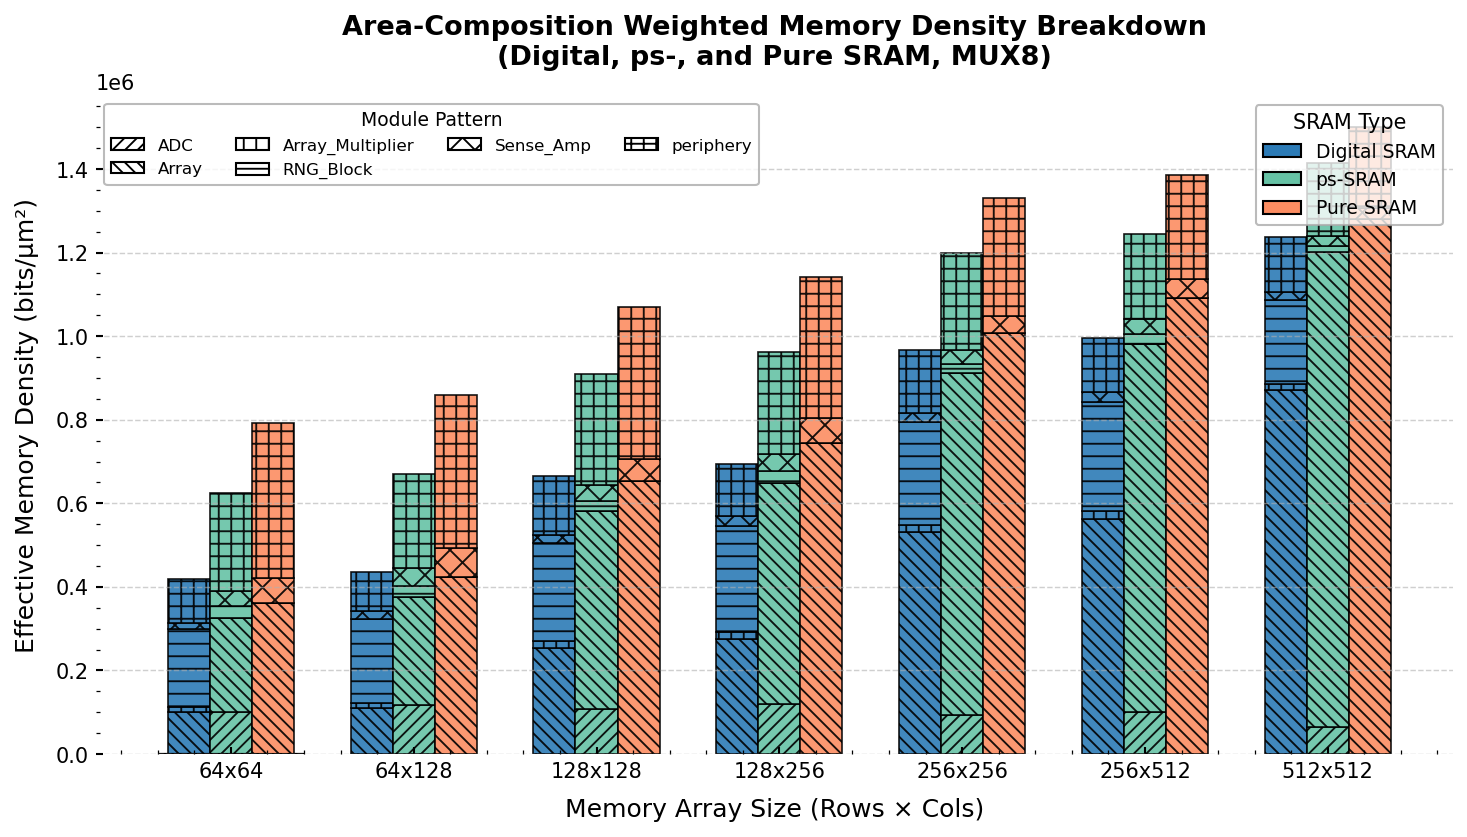

In [32]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ===================== 基础设置 =====================
plt.rcParams['hatch.linewidth'] = 0.9  # hatch 粗细略粗一点，更清晰
plt.rcParams['axes.linewidth'] = 1.2   # 坐标轴更清晰
plt.rcParams['font.family'] = 'DejaVu Sans'  # 字体兼容性好
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数：读取 Breakdown =====================
def load_breakdown(folder, key_density_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()

    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)
        label = f"{data['num_rows']}x{data['num_cols']}"
        exclude_keys = [
            "num_rows", "num_cols", "num_muxed_cols", "num_col_muxed", "adc_precision", "clt_num",
            "MUX_Block","MUX_BLOCK","MUX_Bus","MUX","MUX_Decoder",
            "WL_Decoder","Pre_Charge","Pre_charge","SRAM_Write_Driver",
            "Total Area","Used_area","Used Area",
            "Memory_Density (bits/um^2)","Used_memory_Density (bits/um^2)",
            "Used_Memory_Density (bits/um^2)","Used_memory_density (bits/um^2)"
        ]
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_area = sum(breakdown.values())
        breakdown = {k: v / total_area for k, v in breakdown.items()}  # 模块占比
        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "density": data[key_density_name]
        })
    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 三类 SRAM 文件路径 =====================
ps_folder = "./Data/simulation/ps_sram/4bitADC/ARNG1/mux8/area"
digital_folder = "./Data/simulation/digital_sram/12CLT/mux8/area"
pure_folder = "./Data/simulation/pure_sram/mux8/area"

# ===================== 读取数据 =====================
ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Used_memory_Density (bits/um^2)")
digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Used_memory_density (bits/um^2)")
pure_data, pure_break, pure_mod = load_breakdown(pure_folder, "Used_Memory_Density (bits/um^2)")

modules = sorted(set(ps_mod + dig_mod + pure_mod))  # 统一模块顺序

# ===================== 对齐 Memory Size =====================
memory_sizes = [d["label"] for d in ps_data]
ps_density = [d["density"] for d in ps_data]
digital_density = [d["density"] for d in digital_data]
pure_density = [d["density"] for d in pure_data]

# ===================== 主色与 Pattern =====================
colors = {
    "digital": "#2C7BB6",  # 蓝
    "ps": "#66C2A5",       # 绿
    "pure": "#FC8D62"      # 红
}
hatches = [
    '////',   # 右上斜线
    '\\\\\\\\', # 左上斜线
    '||',     # 垂直条纹
    '--',     # 水平条纹
    'xx',     # 交叉斜线
    '++',     # 十字交叉
    '..',     # 密点
    'oo',     # 圆点
    '**',     # 星点
    'OO'      # 大圆
]

# ===================== 绘图 =====================
plt.figure(figsize=(10, 5.8))  # 更紧凑，论文比例更佳
x = np.arange(len(memory_sizes))
bar_width = 0.23

def plot_stacked(breakdowns, densities, offset, label, base_color):
    bottom = np.zeros(len(memory_sizes))
    for i, module in enumerate(modules):
        vals = []
        for size in memory_sizes:
            frac = breakdowns.get(size, {}).get(module, 0)
            idx = memory_sizes.index(size)
            vals.append(frac * densities[idx])
        plt.bar(
            x + offset, vals, bar_width,
            bottom=bottom,
            color=base_color,
            edgecolor='black',
            hatch=hatches[i % len(hatches)],
            linewidth=0.8,
            alpha=0.9
        )
        bottom += np.array(vals)
    # 类型 legend
    plt.bar(0, 0, color=base_color, edgecolor='black', label=label,alpha=0.9)


# 绘制三类 SRAM（蓝、绿、红）
plot_stacked(digital_break, digital_density, -bar_width, "Digital SRAM", colors["digital"],)
plot_stacked(ps_break, ps_density, 0, "ps-SRAM", colors["ps"])
plot_stacked(pure_break, pure_density, bar_width, "Pure SRAM", colors["pure"])

# ===================== 模块线条图例 =====================
module_handles = [
    Patch(facecolor='white', edgecolor='black', hatch=hatches[i % len(hatches)], label=modules[i])
    for i in range(len(modules))
]

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Effective Memory Density (bits/μm²)", fontsize=12, labelpad=8)
plt.title("Area-Composition Weighted Memory Density Breakdown\n(Digital, ps-, and Pure SRAM, MUX8)",
          fontsize=13, fontweight='bold', pad=15)

plt.grid(axis='y', linestyle='--', alpha=0.6, linewidth=0.7)
plt.tick_params(axis='both', labelsize=10, width=1.0)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

# ===================== 图例设置 =====================
# 上方：类型（颜色）  下方：模块（线条）
type_handles = [
    Patch(facecolor=colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=colors["ps"], edgecolor='black', label='ps-SRAM'),
    Patch(facecolor=colors["pure"], edgecolor='black', label='Pure SRAM')
]

first_legend = plt.legend(handles=type_handles, fontsize=9, loc='upper right',
                          title="SRAM Type", title_fontsize=10, frameon=True)
plt.gca().add_artist(first_legend)

plt.legend(handles=module_handles, fontsize=8, ncol=4, loc='upper left',
           title="Module Pattern", title_fontsize=9, frameon=True)

# ===================== 输出保存 =====================
# os.makedirs("./figure", exist_ok=True)
# plt.savefig("./figure/stacked_density_three_types_beautified.svg",
#             format="svg", dpi=300, bbox_inches="tight")

plt.show()

/var/folders/fz/29pbk9_x3cx_bbdhfpt2f2zc0000gn/T/ipykernel_10088/2659523941.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set3', len(modules))


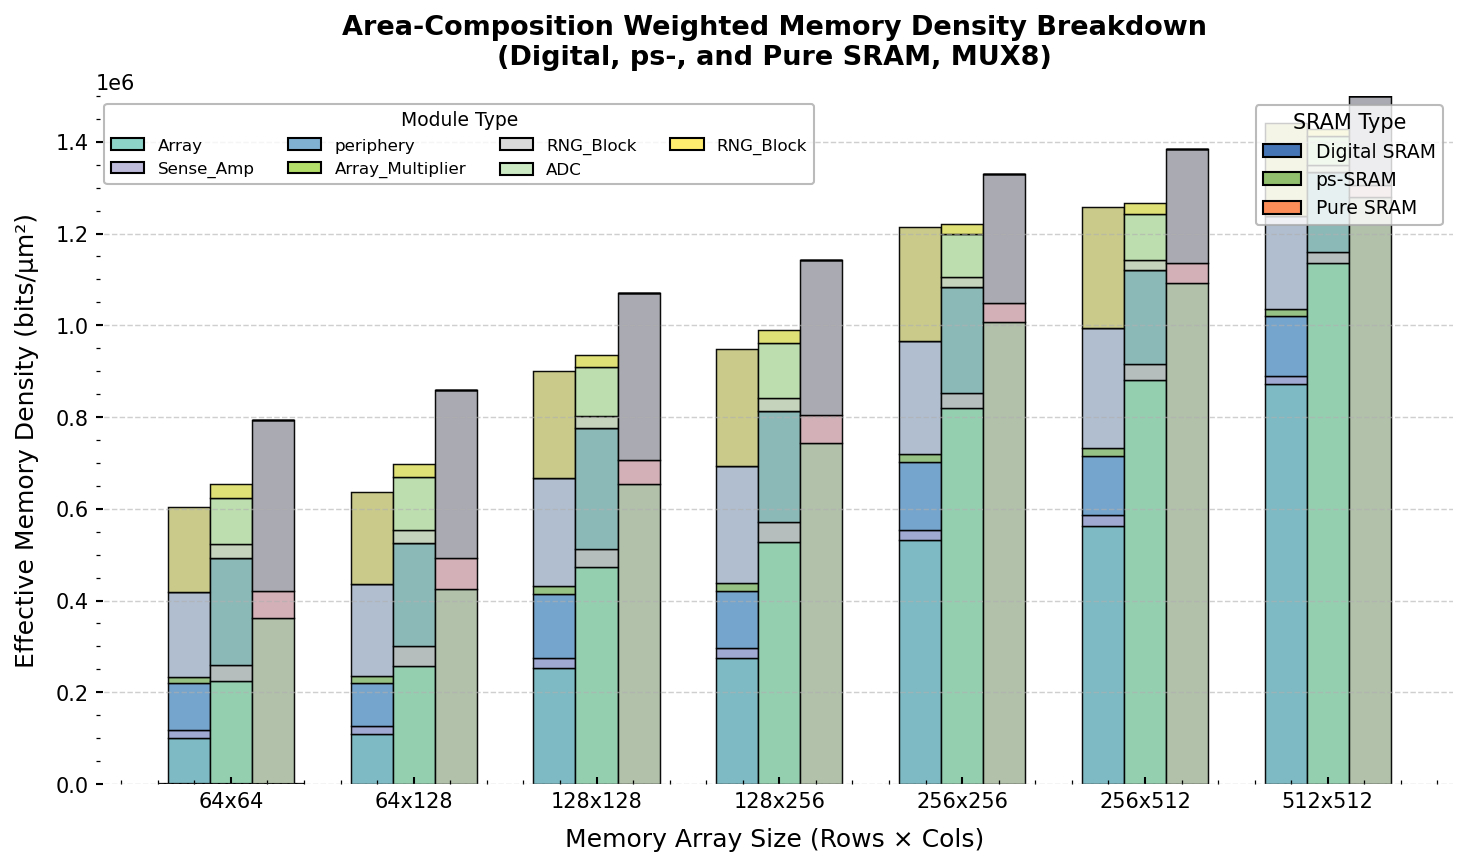

In [40]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.colors import to_rgb

# ===================== 基础设置 =====================
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数 =====================
def load_breakdown(folder, key_density_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()
    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)
        label = f"{data['num_rows']}x{data['num_cols']}"
        exclude_keys = [
            "num_rows", "num_cols", "num_muxed_cols", "num_col_muxed",
            "adc_precision", "clt_num", "MUX_Block","MUX_BLOCK","MUX_Bus",
            "MUX","MUX_Decoder","WL_Decoder","Pre_Charge","Pre_charge",
            "SRAM_Write_Driver","Total Area","Used_area","Used Area",
            "Memory_Density (bits/um^2)","Used_memory_Density (bits/um^2)",
            "Used_Memory_Density (bits/um^2)","Used_memory_density (bits/um^2)"
        ]
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_area = sum(breakdown.values())
        breakdown = {k: v / total_area for k, v in breakdown.items()}  # 模块占比
        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "density": data[key_density_name]
        })
    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 文件路径 =====================
ps_folder = "./Data/simulation/ps_sram/4bitADC/ARNG1/mux8/area"
digital_folder = "./Data/simulation/digital_sram/12CLT/mux8/area"
pure_folder = "./Data/simulation/pure_sram/mux8/area"

ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Used_memory_Density (bits/um^2)")
digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Used_memory_density (bits/um^2)")
pure_data, pure_break, pure_mod = load_breakdown(pure_folder, "Used_Memory_Density (bits/um^2)")

# modules = sorted(set(ps_mod + dig_mod + pure_mod))
# ======== 模块顺序：共同模块在下，独有模块在上 ========

set_ps = set(ps_mod)
set_dig = set(dig_mod)
set_pure = set(pure_mod)

# 共同模块 = 三者都有
common_modules = set_ps & set_dig & set_pure

# 独有模块
ps_only = set_ps - common_modules
dig_only = set_dig - common_modules
pure_only = set_pure - common_modules

# 最终模块顺序：共同底部 → 独有顶部
modules = (
    sorted(common_modules) +
    sorted(dig_only) +
    sorted(ps_only) +    # ADC 会在这里 → 自然排在顶部
    sorted(pure_only)
)

memory_sizes = [d["label"] for d in ps_data]
ps_density = [d["density"] for d in ps_data]
digital_density = [d["density"] for d in digital_data]
pure_density = [d["density"] for d in pure_data]

# ===================== 配色方案 =====================
# 主色
base_colors = {
    "digital": "#4575B4",  # 柔和蓝
    "ps": "#91BF6D",       # 柔和绿
    "pure": "#FC8D59"      # 柔和红
}

# 模块颜色（Set3 更亮更协调）
cmap = cm.get_cmap('Set3', len(modules))
module_colors = [cmap(i) for i in range(len(modules))]

# 辅助函数：颜色混合（在模块颜色上叠加主色调）
def blend_colors(base_color, module_color, alpha=0.3):
    base_rgb = np.array(to_rgb(base_color))
    mod_rgb = np.array(to_rgb(module_color))
    return tuple((1 - alpha) * mod_rgb + alpha * base_rgb)


# ===================== 绘图 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(memory_sizes))
bar_width = 0.23

def plot_stacked(breakdowns, densities, offset, label, base_tint):
    bottom = np.zeros(len(memory_sizes))
    for i, module in enumerate(modules):
        vals = [breakdowns.get(size, {}).get(module, 0) * densities[j]
                for j, size in enumerate(memory_sizes)]
        color = blend_colors(base_tint, module_colors[i], alpha=0.3)
        plt.bar(
            x + offset, vals, bar_width,
            bottom=bottom,
            color=color,
            edgecolor='black',
            linewidth=0.7,
            alpha=0.95
        )
        bottom += np.array(vals)
    plt.bar(0, 0, color = module_colors[i], edgecolor='black', label=label, alpha=0.9)


# 绘制三种 SRAM
plot_stacked(digital_break, digital_density, -bar_width, "Digital SRAM", base_colors["digital"])
plot_stacked(ps_break, ps_density, 0, "ps-SRAM", base_colors["ps"])
plot_stacked(pure_break, pure_density, bar_width, "Pure SRAM", base_colors["pure"])

# ===================== 图例 =====================
module_handles = [
    Patch(facecolor=module_colors[i], edgecolor='black', label=modules[i])
    for i in range(len(modules))
]

type_handles = [
    Patch(facecolor=base_colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=base_colors["ps"], edgecolor='black', label='ps-SRAM'),
    Patch(facecolor=base_colors["pure"], edgecolor='black', label='Pure SRAM')
]

first_legend = plt.legend(handles=type_handles, fontsize=9, loc='upper right',
                          title="SRAM Type", title_fontsize=10, frameon=True)
plt.gca().add_artist(first_legend)

plt.legend(handles=module_handles, fontsize=8, ncol=4, loc='upper left',
           title="Module Type", title_fontsize=9, frameon=True)

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Effective Memory Density (bits/μm²)", fontsize=12, labelpad=8)
plt.title("Area-Composition Weighted Memory Density Breakdown\n(Digital, ps-, and Pure SRAM, MUX8)",
          fontsize=13, fontweight='bold', pad=15)

plt.grid(axis='y', linestyle='--', alpha=0.6, linewidth=0.7)
plt.tick_params(axis='both', labelsize=10)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

# # ===================== 保存 =====================
# os.makedirs("./figure", exist_ok=True)
# plt.savefig("./figure/stacked_density_three_types_color_blend.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()

/var/folders/fz/29pbk9_x3cx_bbdhfpt2f2zc0000gn/T/ipykernel_10088/1333266865.py:102: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set3', len(modules))


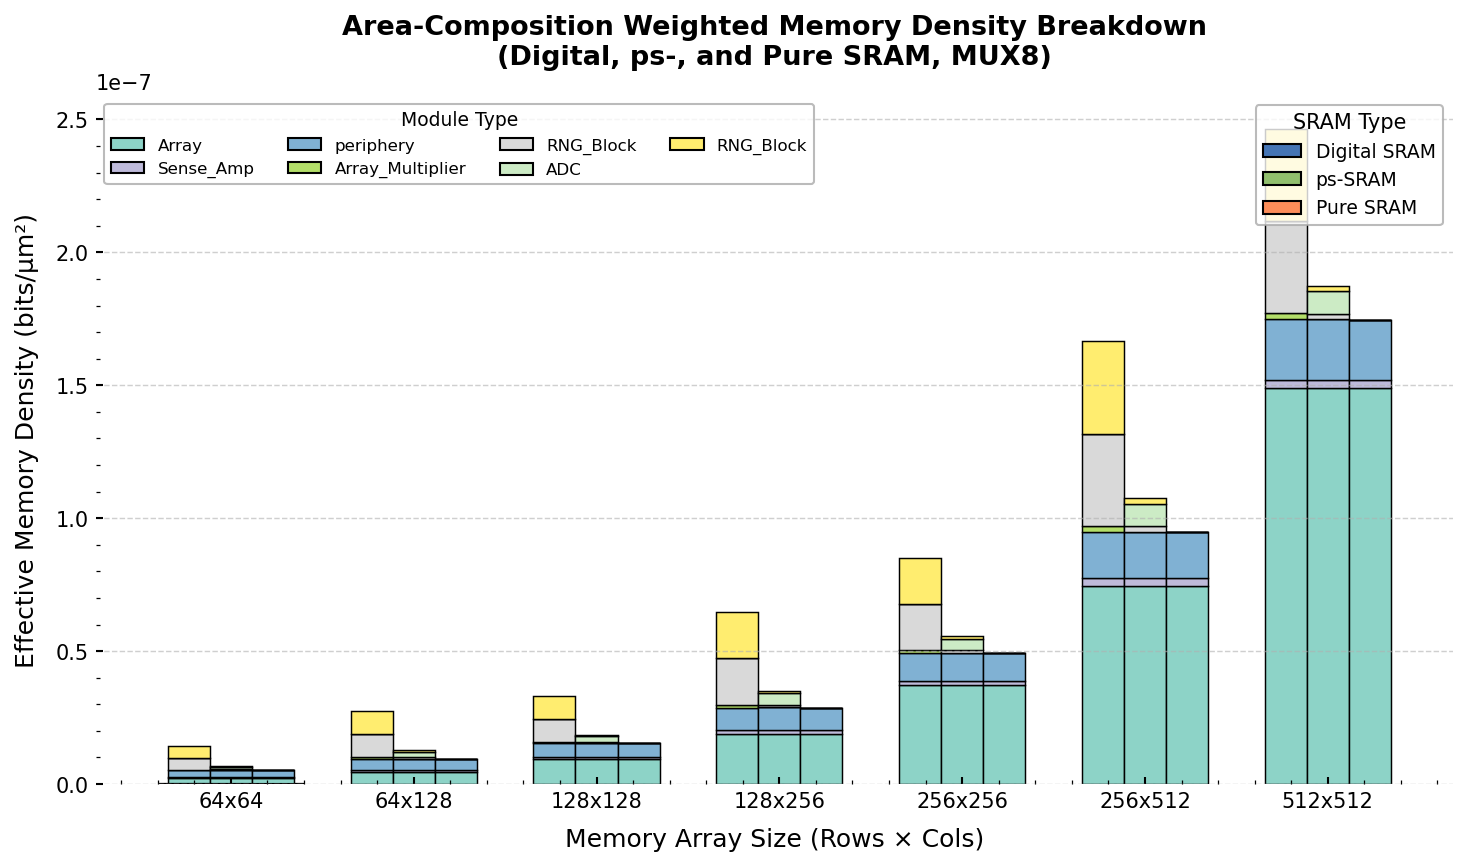

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.colors import to_rgb

# ===================== 基础设置 =====================
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数 =====================
def load_breakdown(folder, key_density_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()
    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)
        label = f"{data['num_rows']}x{data['num_cols']}"
        exclude_keys = [
            "num_rows", "num_cols", "num_muxed_cols", "num_col_muxed",
            "adc_precision", "clt_num", "MUX_Block","MUX_BLOCK","MUX_Bus",
            "MUX","MUX_Decoder","WL_Decoder","Pre_Charge","Pre_charge",
            "SRAM_Write_Driver","Total Area","Used_area","Used Area",
            "Memory_Density (bits/um^2)","Used_memory_Density (bits/um^2)",
            "Used_Memory_Density (bits/um^2)","Used_memory_density (bits/um^2)"
        ]
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_area = sum(breakdown.values())
        breakdown = {k: v / total_area for k, v in breakdown.items()}  # 模块占比
        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "Used_area": data["Used Area"],
            "density": data[key_density_name]
        })
    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 文件路径 =====================
ps_folder = "./Data/simulation/ps_sram/4bitADC/ARNG1/mux8/area"
digital_folder = "./Data/simulation/digital_sram/12CLT/mux8/area"
pure_folder = "./Data/simulation/pure_sram/mux8/area"

ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Used_memory_Density (bits/um^2)")
digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Used_memory_density (bits/um^2)")
pure_data, pure_break, pure_mod = load_breakdown(pure_folder, "Used_Memory_Density (bits/um^2)")


# modules = sorted(set(ps_mod + dig_mod + pure_mod))
# ======== 模块顺序：共同模块在下，独有模块在上 ========

set_ps = set(ps_mod)
set_dig = set(dig_mod)
set_pure = set(pure_mod)

# 共同模块 = 三者都有
common_modules = set_ps & set_dig & set_pure

# 独有模块
ps_only = set_ps - common_modules
dig_only = set_dig - common_modules
pure_only = set_pure - common_modules

# 最终模块顺序：共同底部 → 独有顶部
modules = (
    sorted(common_modules) +
    sorted(dig_only) +
    sorted(ps_only) +    # ADC 会在这里 → 自然排在顶部
    sorted(pure_only)
)
modules = (
    sorted(dig_only) +
    sorted(ps_only) +
    sorted(pure_only) +
    sorted(common_modules)
)

memory_sizes = [d["label"] for d in ps_data]
ps_density = [d["density"] for d in ps_data]
digital_density = [d["density"] for d in digital_data]
pure_density = [d["density"] for d in pure_data]
ps_area = [d["Used_area"] for d in ps_data]
digital_area = [d["Used_area"] for d in digital_data]
pure_area = [d["Used_area"] for d in pure_data]

# ===================== 配色方案 =====================
# 主色
base_colors = {
    "digital": "#4575B4",  # 柔和蓝
    "ps": "#91BF6D",       # 柔和绿
    "pure": "#FC8D59"      # 柔和红
}

# 模块颜色（Set3 更亮更协调）
cmap = cm.get_cmap('Set3', len(modules))
module_colors = [cmap(i) for i in range(len(modules))]

# 辅助函数：颜色混合（在模块颜色上叠加主色调）
def blend_colors(base_color, module_color, alpha=0.3):
    base_rgb = np.array(to_rgb(base_color))
    mod_rgb = np.array(to_rgb(module_color))
    return tuple((1 - alpha) * mod_rgb + alpha * base_rgb)

# ===================== 绘图 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(memory_sizes))
bar_width = 0.23

# -------- 统一透明度 --------
UNIFORM_ALPHA = 1.0

def plot_stacked(breakdowns, densities, offset, label, base_tint):
    """
    绘制单种 SRAM 的堆叠条形图。
    模块顺序由 modules 固定（共同模块底部，独有模块顶部）。
    """
    bottom = np.zeros(len(memory_sizes))

    for i, module in enumerate(modules):
        vals = [
            breakdowns.get(size, {}).get(module, 0) * densities[j]
            for j, size in enumerate(memory_sizes)
        ]

        color = module_colors[i]  # 模块颜色，不混色

        plt.bar(
            x + offset,
            vals,
            bar_width,
            bottom=bottom,
            color=color,
            edgecolor='black',
            linewidth=0.7,
            alpha=UNIFORM_ALPHA
        )

        bottom += np.array(vals)

    # SRAM 类型标签（主色，不参与堆叠）
    plt.bar(
        0, 0,
        color=base_tint,
        edgecolor='black',
        label=label,
        alpha=UNIFORM_ALPHA
    )


# ===================== 绘制三种 SRAM =====================
# plot_stacked(digital_break, digital_density, -bar_width, "Digital SRAM", base_colors["digital"])
# plot_stacked(ps_break, ps_density, 0, "ps-SRAM", base_colors["ps"])
# plot_stacked(pure_break, pure_density, bar_width, "Pure SRAM", base_colors["pure"])
plot_stacked(digital_break, digital_area, -bar_width, "Digital SRAM", base_colors["digital"])
plot_stacked(ps_break, ps_area, 0, "ps-SRAM", base_colors["ps"])
plot_stacked(pure_break, pure_area, bar_width, "Pure SRAM", base_colors["pure"])

# ===================== 图例 =====================
module_handles = [
    Patch(facecolor=module_colors[i], edgecolor='black', label=modules[i], alpha=UNIFORM_ALPHA)
    for i in range(len(modules))
]

type_handles = [
    Patch(facecolor=base_colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=base_colors["ps"], edgecolor='black', label='ps-SRAM'),
    Patch(facecolor=base_colors["pure"], edgecolor='black', label='Pure SRAM')
]

# SRAM 类型图例
first_legend = plt.legend(
    handles=type_handles,
    fontsize=9,
    loc='upper right',
    title="SRAM Type",
    title_fontsize=10,
    frameon=True
)
plt.gca().add_artist(first_legend)

# 模块图例
plt.legend(
    handles=module_handles,
    fontsize=8,
    ncol=4,
    loc='upper left',
    title="Module Type",
    title_fontsize=9,
    frameon=True
)

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Effective Memory Density (bits/μm²)", fontsize=12, labelpad=8)

plt.title(
    "Area-Composition Weighted Memory Density Breakdown\n(Digital, ps-, and Pure SRAM, MUX8)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(axis='y', linestyle='--', alpha=0.6, linewidth=0.7)
plt.tick_params(axis='both', labelsize=10)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

# ===================== 保存 =====================
# os.makedirs("./figure", exist_ok=True)
# plt.savefig("./figure/stacked_area_three_types_color_blend.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/fz/29pbk9_x3cx_bbdhfpt2f2zc0000gn/T/ipykernel_10088/1263670128.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set3', len(modules))


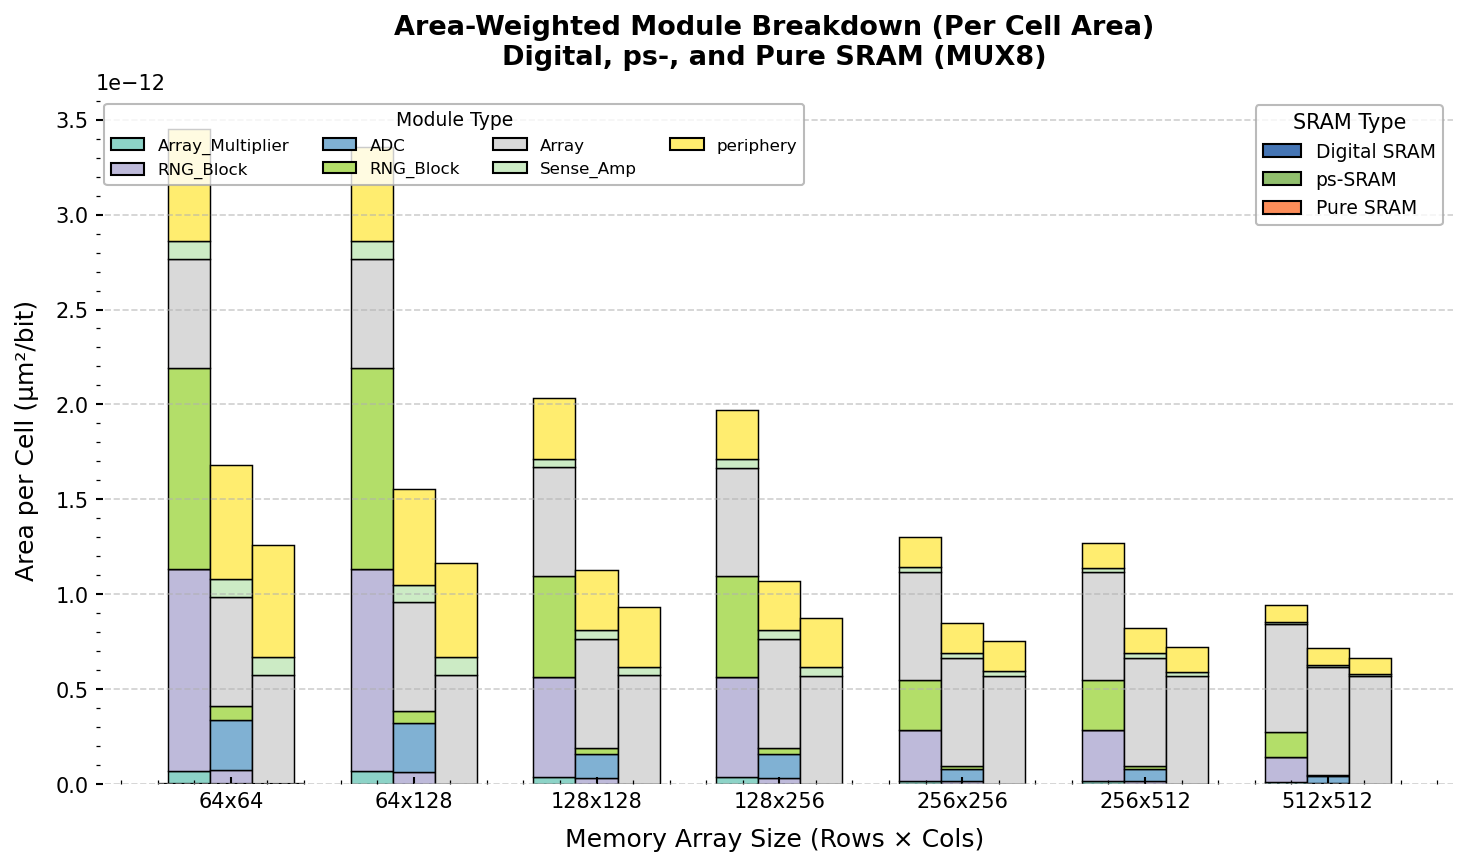

In [85]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.colors import to_rgb

# ===================== 基础设置 =====================
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数 =====================
def load_breakdown(folder, key_density_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()

    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)

        label = f"{data['num_rows']}x{data['num_cols']}"

        exclude_keys = [
            "num_rows", "num_cols", "num_muxed_cols", "num_col_muxed",
            "adc_precision", "clt_num", "MUX_Block","MUX_BLOCK","MUX_Bus",
            "MUX","MUX_Decoder","WL_Decoder","Pre_Charge","Pre_charge",
            "SRAM_Write_Driver","Total Area","Used_area","Used Area",
            "Memory_Density (bits/um^2)","Used_memory_Density (bits/um^2)",
            "Used_Memory_Density (bits/um^2)","Used_memory_density (bits/um^2)"
        ]

        # 提取模块面积
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_area = sum(breakdown.values())
        breakdown = {k: v / total_area for k, v in breakdown.items()}  # 模块占比
        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "Used_area": data["Used Area"],
            "density": data[key_density_name]
        })

    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 文件路径 =====================
ps_folder = "./Data/simulation/ps_sram/4bitADC/ARNG1/mux8/area"
digital_folder = "./Data/simulation/digital_sram/12CLT/mux8/area"
pure_folder = "./Data/simulation/pure_sram/mux8/area"

ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Used_memory_Density (bits/um^2)")
digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Used_memory_density (bits/um^2)")
pure_data, pure_break, pure_mod = load_breakdown(pure_folder, "Used_Memory_Density (bits/um^2)")

# ===================== 模块排序：共同模块在下，独有模块在上 =====================
set_ps = set(ps_mod)
set_dig = set(dig_mod)
set_pure = set(pure_mod)

common_modules = set_ps & set_dig & set_pure
ps_only = set_ps - common_modules
dig_only = set_dig - common_modules
pure_only = set_pure - common_modules

# modules = (
#     sorted(common_modules) +
#     sorted(dig_only) +
#     sorted(ps_only) +
#     sorted(pure_only)
# )

modules = (
    sorted(dig_only) +
    sorted(ps_only) +
    sorted(pure_only) +
    sorted(common_modules)
)

# ===================== Cell Area 计算 =====================
digital_area_per_cell = [
    d["Used_area"] / d["area"] for d in digital_data
]
ps_area_per_cell = [
    d["Used_area"] / d["area"] for d in ps_data
]
pure_area_per_cell = [
    d["Used_area"] / d["area"] for d in pure_data
]

memory_sizes = [d["label"] for d in ps_data]

# ===================== 配色方案 =====================
base_colors = {
    "digital": "#4575B4",
    "ps": "#91BF6D",
    "pure": "#FC8D59"
}

cmap = cm.get_cmap('Set3', len(modules))
module_colors = [cmap(i) for i in range(len(modules))]

UNIFORM_ALPHA = 1.0

# ===================== 绘图函数 =====================
def plot_stacked(breakdowns, values, offset, label, base_tint):
    bottom = np.zeros(len(memory_sizes))

    for i, module in enumerate(modules):
        vals = [
            breakdowns.get(size, {}).get(module, 0) * values[j]
            for j, size in enumerate(memory_sizes)
        ]

        plt.bar(
            x + offset,
            vals,
            bar_width,
            bottom=bottom,
            color=module_colors[i],
            edgecolor='black',
            linewidth=0.7,
            alpha=UNIFORM_ALPHA
        )

        bottom += np.array(vals)

    plt.bar(
        0, 0,
        color=base_tint,
        edgecolor='black',
        label=label,
        alpha=UNIFORM_ALPHA
    )


# ===================== 绘图 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(memory_sizes))
bar_width = 0.23

plot_stacked(digital_break, digital_area_per_cell, -bar_width, "Digital SRAM", base_colors["digital"])
plot_stacked(ps_break, ps_area_per_cell, 0, "ps-SRAM", base_colors["ps"])
plot_stacked(pure_break, pure_area_per_cell, bar_width, "Pure SRAM", base_colors["pure"])

# ===================== 图例 =====================
module_handles = [
    Patch(facecolor=module_colors[i], edgecolor='black', label=modules[i])
    for i in range(len(modules))
]

type_handles = [
    Patch(facecolor=base_colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=base_colors["ps"], edgecolor='black', label='ps-SRAM'),
    Patch(facecolor=base_colors["pure"], edgecolor='black', label='Pure SRAM')
]

first_legend = plt.legend(
    handles=type_handles,
    fontsize=9,
    loc='upper right',
    title="SRAM Type",
    title_fontsize=10,
    frameon=True
)
plt.gca().add_artist(first_legend)

plt.legend(
    handles=module_handles,
    fontsize=8,
    ncol=4,
    loc='upper left',
    title="Module Type",
    title_fontsize=9,
    frameon=True
)

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Area per Cell (μm²/bit)", fontsize=12, labelpad=8)

plt.title(
    "Area-Weighted Module Breakdown (Per Cell Area)\nDigital, ps-, and Pure SRAM (MUX8)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

plt.show()

Common Modules: {'RNG_Block', 'Array', 'periphery', 'Sense_Amp', 'ADC', 'Array_Multiplier'}
Digital-Only Modules: {'Array_Multiplier'}
ps-Only Modules: {'ADC'}
Pure-Only Modules: set()
Digital RNG keys: ['RNG_Block']
ps SRAM RNG keys: ['RNG_Block']


/var/folders/fz/29pbk9_x3cx_bbdhfpt2f2zc0000gn/T/ipykernel_10088/213641913.py:119: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set3', len(modules))


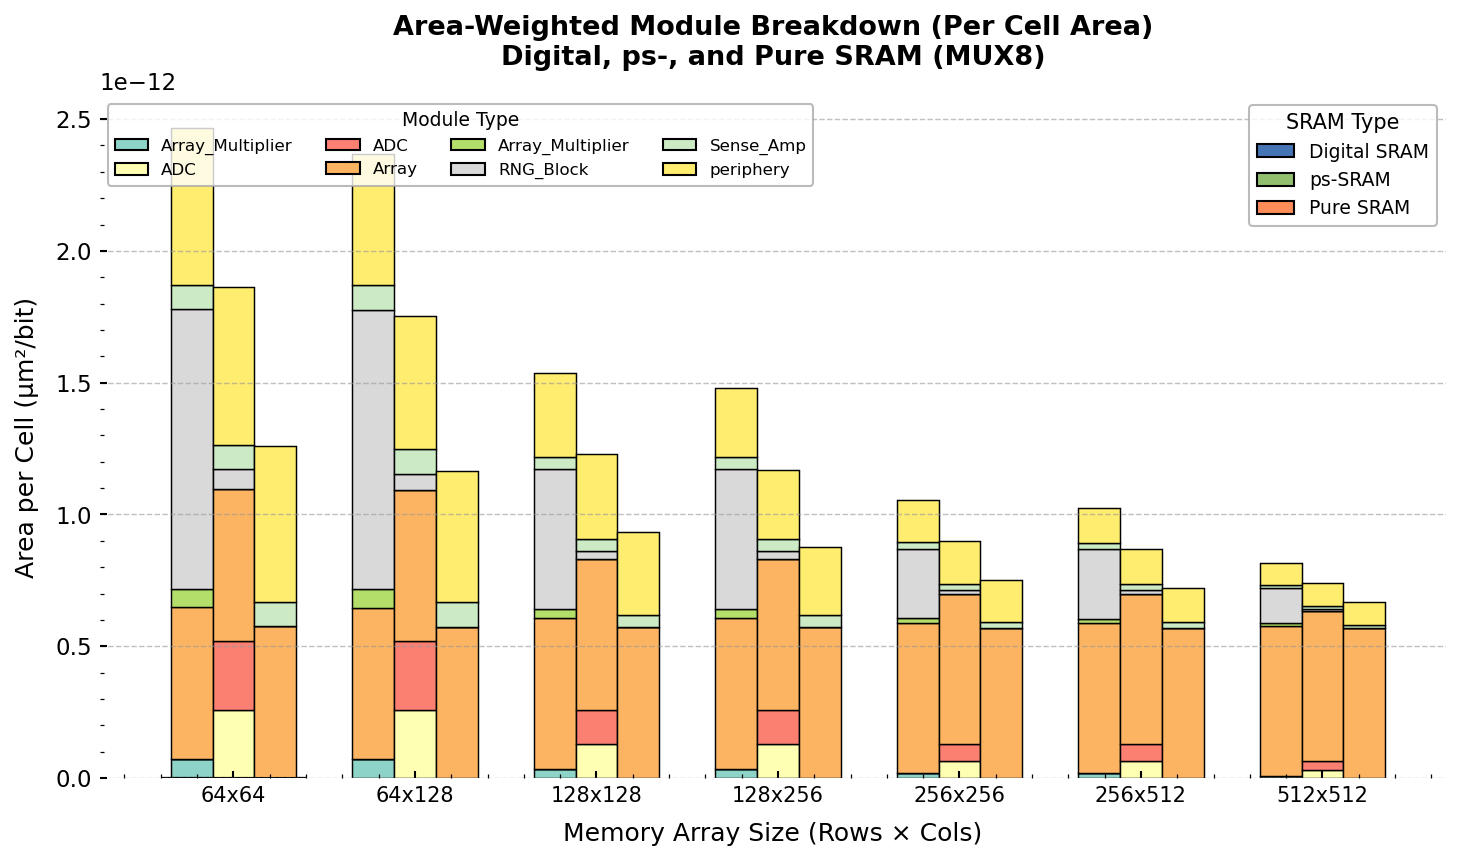

In [146]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.colors import to_rgb

# ===================== 基础设置 =====================
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数 =====================
def load_breakdown(folder, key_density_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()

    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)

        label = f"{data['num_rows']}x{data['num_cols']}"

        exclude_keys = [
            "num_rows", "num_cols", "num_muxed_cols", "num_col_muxed", "Technology",
            "adc_precision", "clt_num", "MUX_Block","MUX_BLOCK","MUX_Bus",
            "MUX","MUX_Decoder","WL_Decoder","Pre_Charge","Pre_charge",
            "SRAM_Write_Driver","Total Area","Used_area","Used Area",
            "Memory_Density (bits/um^2)","Used_memory_Density (bits/um^2)",
            "Used_Memory_Density (bits/um^2)","Used_memory_density (bits/um^2)"
        ]

        # 提取模块面积
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_area = sum(breakdown.values())
        breakdown = {k: v / total_area for k, v in breakdown.items()}  # 模块占比
        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "Used_area": data["Used Area"],
            "density": data[key_density_name]
        })

    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 文件路径 =====================
ps_folder = "./Data/simulation/ps_sram/65/4bitADC/ARNG1/mux8/area"
digital_folder = "./Data/simulation/digital_sram/12CLT/mux8/area"
pure_folder = "./Data/simulation/pure_sram/mux8/area"

ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Used_memory_Density (bits/um^2)")
digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Used_memory_density (bits/um^2)")
pure_data, pure_break, pure_mod = load_breakdown(pure_folder, "Used_Memory_Density (bits/um^2)")

# ===================== 模块排序：共同模块在下，独有模块在上 =====================
# 模块全集（不考虑是否某 SRAM 为 0）
set_ps = set(ps_mod)
set_dig = set(dig_mod)
set_pure = set(pure_mod)

# 共同模块：只看命名，不看是否某些 size 有 0
common_modules = set_ps | set_dig | set_pure

# 独有模块（几乎不会发生，除非名字真不同）
ps_only = set_ps - (set_dig | set_pure)
dig_only = set_dig - (set_ps | set_pure)
pure_only = set_pure - (set_ps | set_dig)

# common_modules = set_ps & set_dig & set_pure
# ps_only = set_ps - common_modules
# dig_only = set_dig - common_modules
# pure_only = set_pure - common_modules
print("Common Modules:", common_modules)
print("Digital-Only Modules:", dig_only)
print("ps-Only Modules:", ps_only)
print("Pure-Only Modules:", pure_only)
# modules = (
#     sorted(common_modules) +
#     sorted(dig_only) +
#     sorted(ps_only) +
#     sorted(pure_only)
# )

modules = (
    sorted(dig_only) +
    sorted(ps_only) +
    sorted(pure_only) +
    sorted(common_modules)
)

print("Digital RNG keys:", [k for k in digital_break[next(iter(digital_break))].keys() if "RNG" in k.upper()])
print("ps SRAM RNG keys:", [k for k in ps_break[next(iter(ps_break))].keys() if "RNG" in k.upper()])
# ===================== Cell Area 计算 =====================
digital_area_per_cell = [
    d["Used_area"] / d["area"] for d in digital_data
]
ps_area_per_cell = [
    d["Used_area"] / d["area"] for d in ps_data
]
pure_area_per_cell = [
    d["Used_area"] / d["area"] for d in pure_data
]

memory_sizes = [d["label"] for d in ps_data]

# ===================== 配色方案 =====================
base_colors = {
    "digital": "#4575B4",
    "ps": "#91BF6D",
    "pure": "#FC8D59"
}

cmap = cm.get_cmap('Set3', len(modules))
module_colors = [cmap(i) for i in range(len(modules))]

UNIFORM_ALPHA = 1.0

# ===================== 绘图函数 =====================
def plot_stacked(breakdowns, values, offset, label, base_tint):
    bottom = np.zeros(len(memory_sizes))

    for i, module in enumerate(modules):
        vals = [
            breakdowns.get(size, {}).get(module, 0) * values[j]
            for j, size in enumerate(memory_sizes)
        ]

        plt.bar(
            x + offset,
            vals,
            bar_width,
            bottom=bottom,
            color=module_colors[i],
            edgecolor='black',
            linewidth=0.7,
            alpha=UNIFORM_ALPHA
        )

        bottom += np.array(vals)

    plt.bar(
        0, 0,
        color=base_tint,
        edgecolor='black',
        label=label,
        alpha=UNIFORM_ALPHA
    )


# ===================== 绘图 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(memory_sizes))
bar_width = 0.23

plot_stacked(digital_break, digital_area_per_cell, -bar_width, "Digital SRAM", base_colors["digital"])
plot_stacked(ps_break, ps_area_per_cell, 0, "ps-SRAM", base_colors["ps"])
plot_stacked(pure_break, pure_area_per_cell, bar_width, "Pure SRAM", base_colors["pure"])

# ===================== 图例 =====================
module_handles = [
    Patch(facecolor=module_colors[i], edgecolor='black', label=modules[i])
    for i in range(len(modules))
]

type_handles = [
    Patch(facecolor=base_colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=base_colors["ps"], edgecolor='black', label='ps-SRAM'),
    Patch(facecolor=base_colors["pure"], edgecolor='black', label='Pure SRAM')
]

first_legend = plt.legend(
    handles=type_handles,
    fontsize=9,
    loc='upper right',
    title="SRAM Type",
    title_fontsize=10,
    frameon=True
)
plt.gca().add_artist(first_legend)

plt.legend(
    handles=module_handles,
    fontsize=8,
    ncol=4,
    loc='upper left',
    title="Module Type",
    title_fontsize=9,
    frameon=True
)

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Area per Cell (μm²/bit)", fontsize=12, labelpad=8)

plt.title(
    "Area-Weighted Module Breakdown (Per Cell Area)\nDigital, ps-, and Pure SRAM (MUX8)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

# ===================== 保存 =====================
# os.makedirs("./figure", exist_ok=True)
# plt.savefig("./figure/stacked_area_three_types_color_blend.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [145]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.colors import to_rgb

# ===================== 基础设置 =====================
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数 =====================
def load_breakdown(folder, key_latency_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()

    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)

        label = f"{data['num_rows']}x{data['num_cols']}"

        exclude_keys = [
            "num_rows", "num_cols", "num_muxed_cols", "num_col_muxed",
            "adc_precision", "clt_num",
            "MUX_Bus", "MUX", "MUX_Decoder", "MUX_Block", "MUX_BLOCK",
            "WL_Decoder", "Pre_Charge", "Pre_charge", "Precharger",
            "SRAM_Write_Driver",
            "Total Read Latency (s)", "Total Read Latency (cycles)",
            "Throughput (bits/s)"
        ]

        # 提取模块面积
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_area = sum(breakdown.values())
        breakdown = {k: v / total_area for k, v in breakdown.items()}  # 模块占比

        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "latency": data[key_latency_name]
        })

    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 文件路径 =====================
ps_folder = "./Data/simulation/ps_sram/4bitADC/ARNG1/mux8/latency"
digital_folder = "./Data/simulation/digital_sram/12CLT/mux8/latency"

ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Total Read Latency (s)")
digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Total Read Latency (s)")

# ===================== 模块排序（共同模块在下，独有模块在上） =====================
set_ps = set(ps_mod)
set_dig = set(dig_mod)

common_modules = set_ps & set_dig
ps_only = set_ps - common_modules
dig_only = set_dig - common_modules

modules = (
    sorted(common_modules) +
    sorted(dig_only) +
    sorted(ps_only)
)
modules = (
    sorted(dig_only) +
    sorted(ps_only) +
    sorted(pure_only) +
    sorted(common_modules)
)

# ===================== 数据提取 =====================
memory_sizes = [d["label"] for d in ps_data]
ps_latency = [d["latency"] for d in ps_data]
digital_latency = [d["latency"] for d in digital_data]

# ===================== 配色方案 =====================
base_colors = {
    "digital": "#4575B4",
    "ps": "#91BF6D"
}

cmap = cm.get_cmap('Set3', len(modules))
module_colors = [cmap(i) for i in range(len(modules))]

# ===================== 绘图 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(memory_sizes))
bar_width = 0.23
UNIFORM_ALPHA = 1.0

def plot_stacked(breakdowns, latency, offset, label, base_tint):
    bottom = np.zeros(len(memory_sizes))
    for i, module in enumerate(modules):
        vals = [
            breakdowns.get(size, {}).get(module, 0) * latency[j]
            for j, size in enumerate(memory_sizes)
        ]
        color = module_colors[i]

        plt.bar(
            x + offset,
            vals,
            bar_width,
            bottom=bottom,
            color=color,
            edgecolor='black',
            linewidth=0.7,
            alpha=UNIFORM_ALPHA
        )

        bottom += np.array(vals)

    plt.bar(0, 0, color=base_tint, edgecolor='black', label=label, alpha=UNIFORM_ALPHA)


# ===================== 主图 =====================
plot_stacked(digital_break, digital_latency, -bar_width, "Digital SRAM", base_colors["digital"])
plot_stacked(ps_break, ps_latency, 0, "ps-SRAM", base_colors["ps"])

# ===================== 图例 =====================
module_handles = [
    Patch(facecolor=module_colors[i], edgecolor='black', label=modules[i], alpha=UNIFORM_ALPHA)
    for i in range(len(modules))
]

type_handles = [
    Patch(facecolor=base_colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=base_colors["ps"], edgecolor='black', label='ps-SRAM')
]

# SRAM 类型图例
first_legend = plt.legend(
    handles=type_handles,
    fontsize=9,
    loc='upper right',
    title="SRAM Type",
    title_fontsize=10,
    frameon=True
)
plt.gca().add_artist(first_legend)

# 模块图例
plt.legend(
    handles=module_handles,
    fontsize=8,
    ncol=4,
    loc='upper left',
    title="Module Type",
    title_fontsize=9,
    frameon=True
)

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Read Latency (s)", fontsize=12, labelpad=8)

plt.title(
    "Latency Composition Breakdown\n(Digital SRAM vs. ps-SRAM, MUX8)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(axis='y', linestyle='--', alpha=0.6, linewidth=0.7)
plt.tick_params(axis='both', labelsize=10)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

# ===================== 保存 =====================
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/stacked_latency_two_types.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './Data/simulation/ps_sram/4bitADC/ARNG1/mux8/latency'

/var/folders/fz/29pbk9_x3cx_bbdhfpt2f2zc0000gn/T/ipykernel_10088/2396969581.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set3', len(modules))


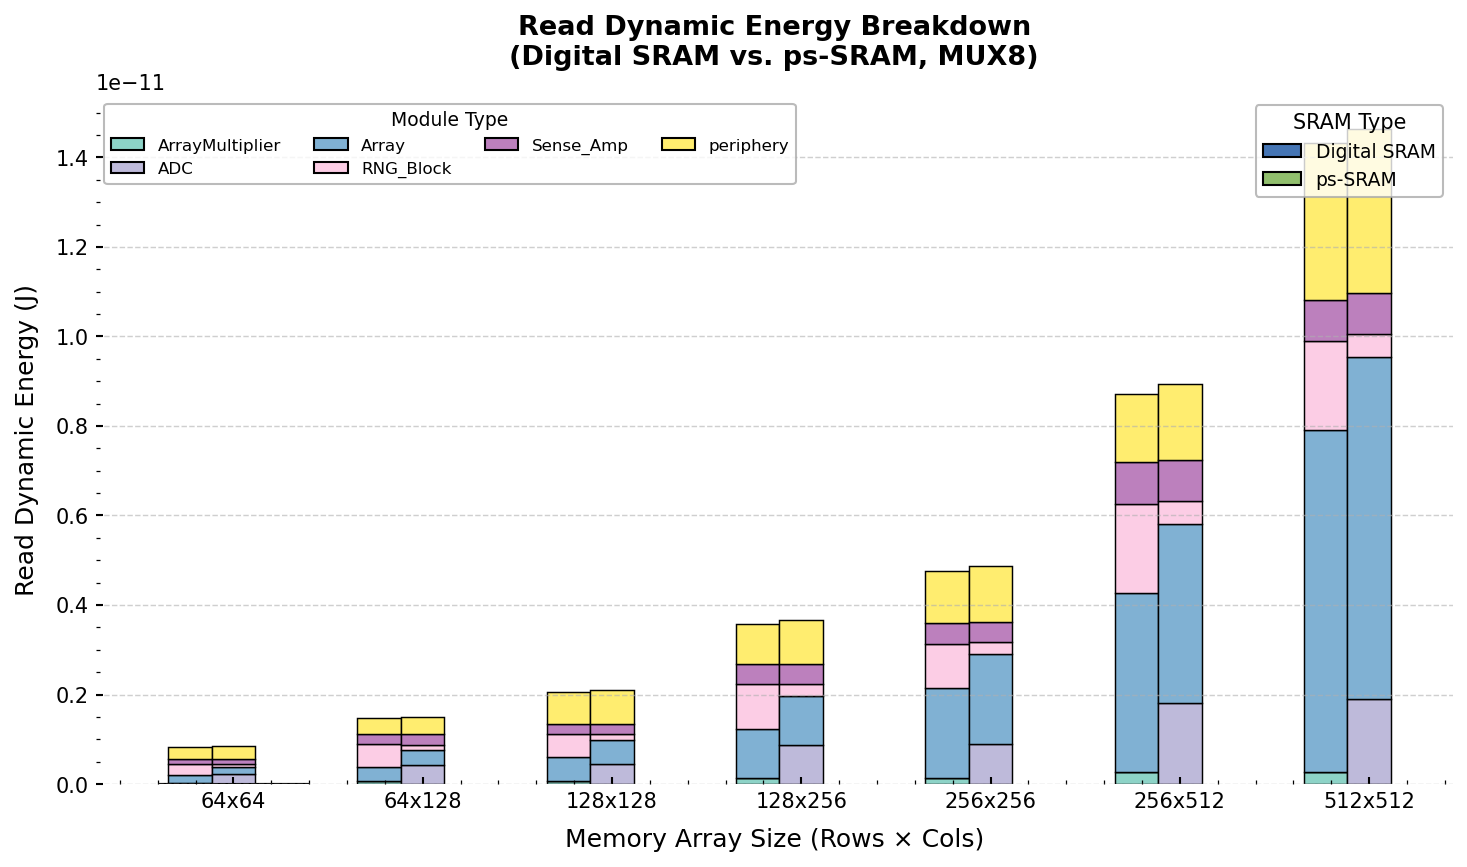

In [91]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.colors import to_rgb

# ===================== 基础设置 =====================
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数 =====================
def load_breakdown(folder, key_energy_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()

    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)

        label = f"{data['num_rows']}x{data['num_cols']}"

        exclude_keys = [
            "num_rows", "num_cols", "num_muxed_cols", "num_col_muxed",
            "adc_precision", "clt_num",
            "MUX_Bus", "MUX", "MUX_Decoder", "MUX_Block", "MUX_BLOCK",
            "WL_Decoder", "Pre_Charge", "Pre_charge", "Precharger",
            "SRAM_Write_Driver",
            "Total Read Dynamic Energy (J)", "Leakage Power (W)",
            "Total Read Latency (s)", "Total Read Latency (cycles)",
            "Throughput (bits/s)"
        ]

        # 提取模块动态能量
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_energy = sum(breakdown.values())
        breakdown = {k: v / total_energy for k, v in breakdown.items()}  # 模块占比

        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "energy": data[key_energy_name]
        })

    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 文件路径 =====================
ps_folder = "./Data/simulation/ps_sram/4bitADC/ARNG1/mux8/energy"
digital_folder = "./Data/simulation/digital_sram/12CLT/mux8/energy"

ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Total Read Dynamic Energy (J)")
digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Total Read Dynamic Energy (J)")

# ===================== 模块排序：共同在下，独有在上 =====================
set_ps = set(ps_mod)
set_dig = set(dig_mod)

common_modules = set_ps & set_dig
ps_only = set_ps - common_modules
dig_only = set_dig - common_modules

modules = (
    sorted(common_modules) +
    sorted(dig_only) +
    sorted(ps_only)
)
modules = (
    sorted(dig_only) +
    sorted(ps_only) +
    sorted(pure_only) +
    sorted(common_modules)
)
# ===================== 提取数据 =====================
memory_sizes = [d["label"] for d in ps_data]
ps_energy = [d["energy"] for d in ps_data]
digital_energy = [d["energy"] for d in digital_data]

# ===================== 配色方案 =====================
base_colors = {
    "digital": "#4575B4",
    "ps": "#91BF6D"
}

cmap = cm.get_cmap('Set3', len(modules))
module_colors = [cmap(i) for i in range(len(modules))]

# ===================== 绘图 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(memory_sizes))
bar_width = 0.23
UNIFORM_ALPHA = 1.0

def plot_stacked(breakdowns, energies, offset, label, base_tint):
    bottom = np.zeros(len(memory_sizes))

    for i, module in enumerate(modules):
        vals = [
            breakdowns.get(size, {}).get(module, 0) * energies[j]
            for j, size in enumerate(memory_sizes)
        ]

        plt.bar(
            x + offset,
            vals,
            bar_width,
            bottom=bottom,
            color=module_colors[i],
            edgecolor='black',
            linewidth=0.7,
            alpha=UNIFORM_ALPHA
        )

        bottom += np.array(vals)

    # 主标签
    plt.bar(
        0, 0,
        color=base_tint,
        edgecolor='black',
        label=label,
        alpha=UNIFORM_ALPHA
    )


# ===================== 主图 =====================
plot_stacked(digital_break, digital_energy, -bar_width, "Digital SRAM", base_colors["digital"])
plot_stacked(ps_break, ps_energy, 0, "ps-SRAM", base_colors["ps"])

# ===================== 图例 =====================
module_handles = [
    Patch(facecolor=module_colors[i], edgecolor='black', label=modules[i])
    for i in range(len(modules))
]

type_handles = [
    Patch(facecolor=base_colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=base_colors["ps"], edgecolor='black', label='ps-SRAM')
]

first_legend = plt.legend(
    handles=type_handles,
    fontsize=9,
    loc='upper right',
    title="SRAM Type",
    title_fontsize=10,
    frameon=True
)
plt.gca().add_artist(first_legend)

plt.legend(
    handles=module_handles,
    fontsize=8,
    ncol=4,
    loc='upper left',
    title="Module Type",
    title_fontsize=9,
    frameon=True
)

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Read Dynamic Energy (J)", fontsize=12, labelpad=8)

plt.title(
    "Read Dynamic Energy Breakdown\n(Digital SRAM vs. ps-SRAM, MUX8)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(axis='y', linestyle='--', alpha=0.6, linewidth=0.7)
plt.tick_params(axis='both', labelsize=10)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

# ===================== 保存 =====================
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/stacked_energy_two_types.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()

/var/folders/fz/29pbk9_x3cx_bbdhfpt2f2zc0000gn/T/ipykernel_10088/751039518.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set3', len(modules))


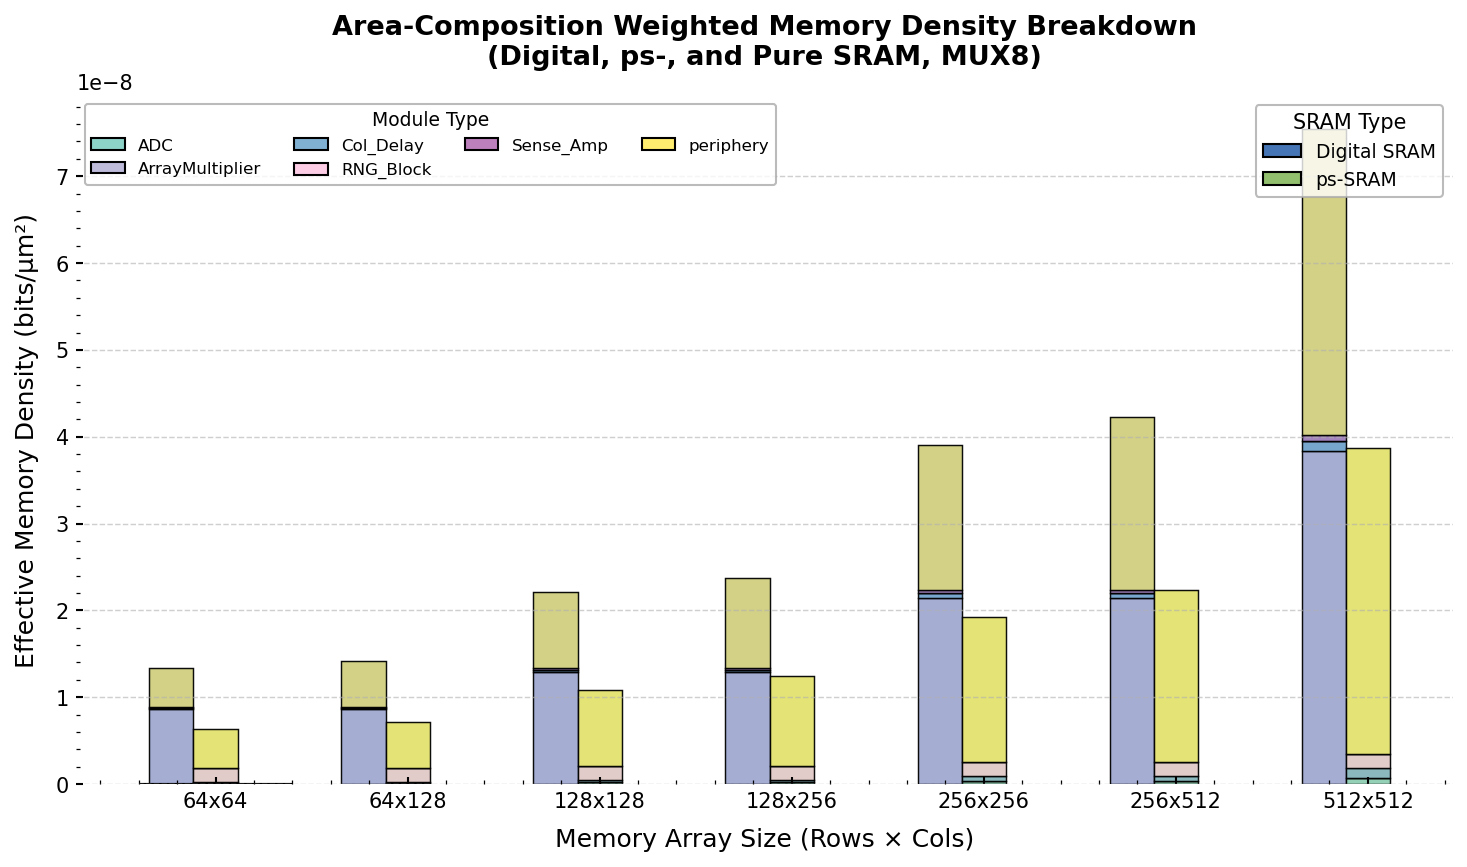

In [34]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.colors import to_rgb

# ===================== 基础设置 =====================
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数 =====================
def load_breakdown(folder, key_density_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()
    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)
        label = f"{data['num_rows']}x{data['num_cols']}"
        exclude_keys = [
            "num_rows", "num_cols", "num_col_muxed","MUX_Bus","MUX","MUX_Decoder","MUX_Block","WL_Decoder",
            "Pre_Charge","Pre_charge","SRAM_Write_Driver","num_muxed_cols","adc_precision","MUX_BLOCK","Precharger",
            "Total Read Latency (s)","Throughput (bits/s)", "Total Read Latency (cycles)",
            "num_rows", "num_cols", "clt_num",
            "MUX_Bus", "MUX", "MUX_Decoder",
            "Throughput (bits/s)", "Total Read Latency (s)", "Total Read Latency (cycles)"
        ]
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_area = sum(breakdown.values())
        breakdown = {k: v / total_area for k, v in breakdown.items()}  # 模块占比
        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "density": data[key_density_name]
        })
    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 文件路径 =====================
ps_folder = "./Data/simulation/ps_sram/4bitADC/ARNG1/mux8/latency"
digital_folder = "./Data/simulation/digital_sram/12CLT/mux8/latency"
# pure_folder = "./Data/simulation/pure_sram/mux8/area"

ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Total Read Latency (s)")
digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Total Read Latency (s)")
# pure_data, pure_break, pure_mod = load_breakdown(pure_folder, "Used_Memory_Density (bits/um^2)")

modules = sorted(set(ps_mod + dig_mod))

memory_sizes = [d["label"] for d in ps_data]
ps_density = [d["density"] for d in ps_data]
digital_density = [d["density"] for d in digital_data]
# pure_density = [d["density"] for d in pure_data]

# ===================== 配色方案 =====================
# 主色
base_colors = {
    "digital": "#4575B4",  # 柔和蓝
    "ps": "#91BF6D",       # 柔和绿
    "pure": "#FC8D59"      # 柔和红
}

# 模块颜色（Set3 更亮更协调）
cmap = cm.get_cmap('Set3', len(modules))
module_colors = [cmap(i) for i in range(len(modules))]

# 辅助函数：颜色混合（在模块颜色上叠加主色调）
def blend_colors(base_color, module_color, alpha=0.3):
    base_rgb = np.array(to_rgb(base_color))
    mod_rgb = np.array(to_rgb(module_color))
    return tuple((1 - alpha) * mod_rgb + alpha * base_rgb)


# ===================== 绘图 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(memory_sizes))
bar_width = 0.23

def plot_stacked(breakdowns, densities, offset, label, base_tint):
    bottom = np.zeros(len(memory_sizes))
    for i, module in enumerate(modules):
        vals = [breakdowns.get(size, {}).get(module, 0) * densities[j]
                for j, size in enumerate(memory_sizes)]
        color = blend_colors(base_tint, module_colors[i], alpha=0.25)
        plt.bar(
            x + offset, vals, bar_width,
            bottom=bottom,
            color=color,
            edgecolor='black',
            linewidth=0.7,
            alpha=0.95
        )
        bottom += np.array(vals)
    plt.bar(0, 0, color=base_tint, edgecolor='black', label=label, alpha=0.95)


# 绘制三种 SRAM
plot_stacked(digital_break, digital_density, -bar_width, "Digital SRAM", base_colors["digital"])
plot_stacked(ps_break, ps_density, 0, "ps-SRAM", base_colors["ps"])
# plot_stacked(pure_break, pure_density, bar_width, "Pure SRAM", base_colors["pure"])

# ===================== 图例 =====================
module_handles = [
    Patch(facecolor=module_colors[i], edgecolor='black', label=modules[i])
    for i in range(len(modules))
]

type_handles = [
    Patch(facecolor=base_colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=base_colors["ps"], edgecolor='black', label='ps-SRAM')
    # Patch(facecolor=base_colors["pure"], edgecolor='black', label='Pure SRAM')
]

first_legend = plt.legend(handles=type_handles, fontsize=9, loc='upper right',
                          title="SRAM Type", title_fontsize=10, frameon=True)
plt.gca().add_artist(first_legend)

plt.legend(handles=module_handles, fontsize=8, ncol=4, loc='upper left',
           title="Module Type", title_fontsize=9, frameon=True)

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Effective Memory Density (bits/μm²)", fontsize=12, labelpad=8)
plt.title("Area-Composition Weighted Memory Density Breakdown\n(Digital, ps-, and Pure SRAM, MUX8)",
          fontsize=13, fontweight='bold', pad=15)

plt.grid(axis='y', linestyle='--', alpha=0.6, linewidth=0.7)
plt.tick_params(axis='both', labelsize=10)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

# ===================== 保存 =====================
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/stacked_latency_three_types_color_blend.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()

/var/folders/fz/29pbk9_x3cx_bbdhfpt2f2zc0000gn/T/ipykernel_10088/3340250671.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set3', len(modules))


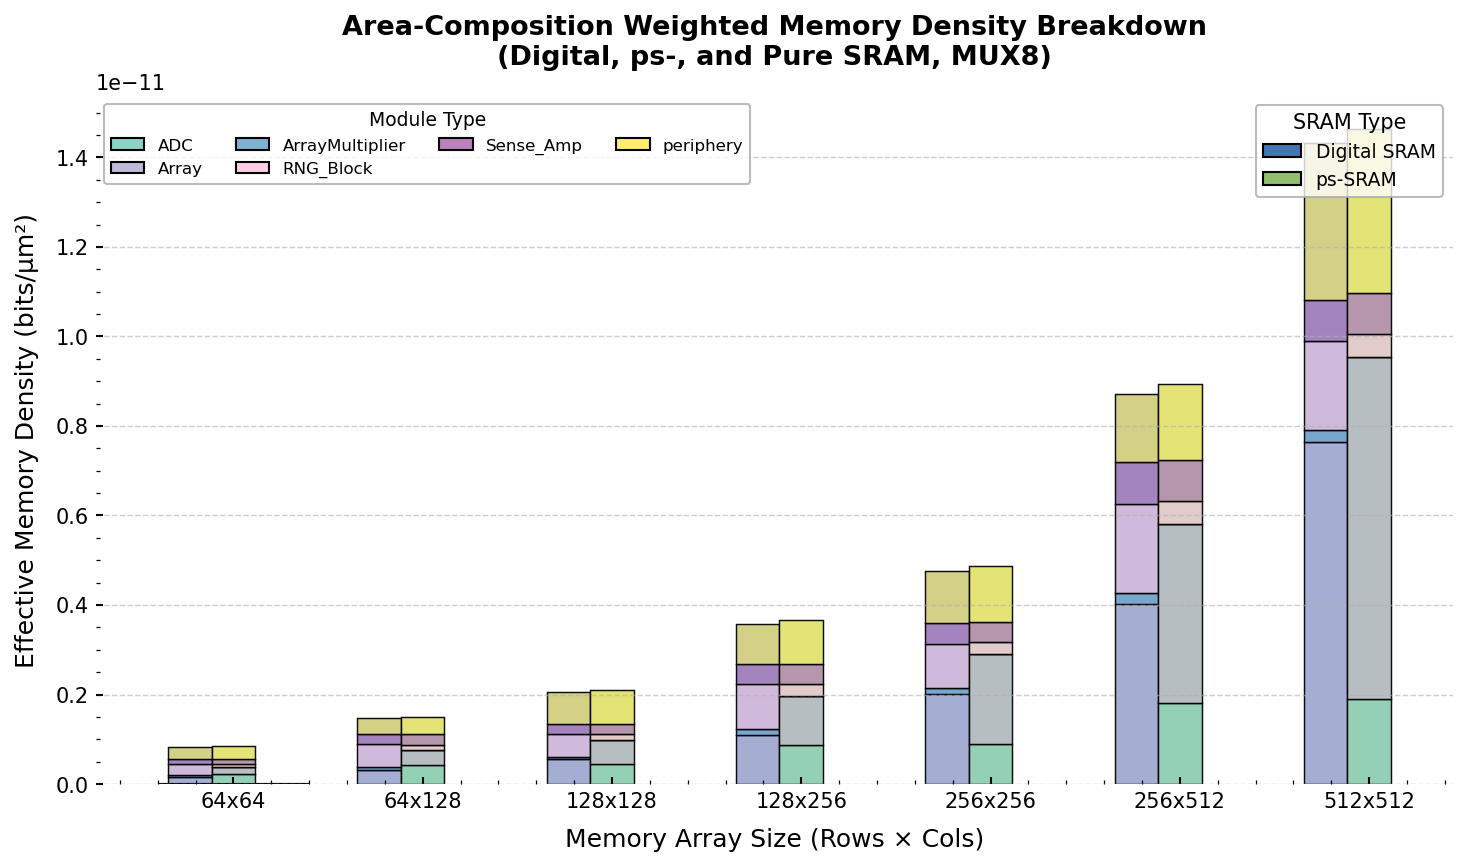

In [35]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.colors import to_rgb

# ===================== 基础设置 =====================
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数 =====================
def load_breakdown(folder, key_density_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()
    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)
        label = f"{data['num_rows']}x{data['num_cols']}"
        exclude_keys = [
            "num_rows", "num_cols", "num_muxed_cols", "adc_precision","MUX_Bus","MUX","MUX_Decoder","MUX_Block",
            "wl_decoder_leakage", "precharger_leakage", "sram_write_driver_leakage",
            "Total Read Dynamic Energy (J)", "Leakage Power (W)","num_rows", "num_cols", "clt_num", "MUX_Bus", "MUX", "MUX_Decoder",
            "Total Read Dynamic Energy (J)","WL_Decoder","Pre_Charge","Pre_charge","SRAM_Write_Driver","Precharger",
        ]
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_area = sum(breakdown.values())
        breakdown = {k: v / total_area for k, v in breakdown.items()}  # 模块占比
        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "density": data[key_density_name]
        })
    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 文件路径 =====================
ps_folder = "./Data/simulation/ps_sram/4bitADC/ARNG1/mux8/energy"
digital_folder = "./Data/simulation/digital_sram/12CLT/mux8/energy"
# pure_folder = "./Data/simulation/pure_sram/mux8/area"

ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Total Read Dynamic Energy (J)")
digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Total Read Dynamic Energy (J)")
# pure_data, pure_break, pure_mod = load_breakdown(pure_folder, "Used_Memory_Density (bits/um^2)")

modules = sorted(set(ps_mod + dig_mod))

memory_sizes = [d["label"] for d in ps_data]
ps_density = [d["density"] for d in ps_data]
digital_density = [d["density"] for d in digital_data]
# pure_density = [d["density"] for d in pure_data]

# ===================== 配色方案 =====================
# 主色
base_colors = {
    "digital": "#4575B4",  # 柔和蓝
    "ps": "#91BF6D",       # 柔和绿
    "pure": "#FC8D59"      # 柔和红
}

# 模块颜色（Set3 更亮更协调）
cmap = cm.get_cmap('Set3', len(modules))
module_colors = [cmap(i) for i in range(len(modules))]

# 辅助函数：颜色混合（在模块颜色上叠加主色调）
def blend_colors(base_color, module_color, alpha=0.3):
    base_rgb = np.array(to_rgb(base_color))
    mod_rgb = np.array(to_rgb(module_color))
    return tuple((1 - alpha) * mod_rgb + alpha * base_rgb)


# ===================== 绘图 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(memory_sizes))
bar_width = 0.23

def plot_stacked(breakdowns, densities, offset, label, base_tint):
    bottom = np.zeros(len(memory_sizes))
    for i, module in enumerate(modules):
        vals = [breakdowns.get(size, {}).get(module, 0) * densities[j]
                for j, size in enumerate(memory_sizes)]
        color = blend_colors(base_tint, module_colors[i], alpha=0.25)
        plt.bar(
            x + offset, vals, bar_width,
            bottom=bottom,
            color=color,
            edgecolor='black',
            linewidth=0.7,
            alpha=0.95
        )
        bottom += np.array(vals)
    plt.bar(0, 0, color=base_tint, edgecolor='black', label=label, alpha=0.95)


# 绘制三种 SRAM
plot_stacked(digital_break, digital_density, -bar_width, "Digital SRAM", base_colors["digital"])
plot_stacked(ps_break, ps_density, 0, "ps-SRAM", base_colors["ps"])
# plot_stacked(pure_break, pure_density, bar_width, "Pure SRAM", base_colors["pure"])

# ===================== 图例 =====================
module_handles = [
    Patch(facecolor=module_colors[i], edgecolor='black', label=modules[i])
    for i in range(len(modules))
]

type_handles = [
    Patch(facecolor=base_colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=base_colors["ps"], edgecolor='black', label='ps-SRAM')
    # Patch(facecolor=base_colors["pure"], edgecolor='black', label='Pure SRAM')
]

first_legend = plt.legend(handles=type_handles, fontsize=9, loc='upper right',
                          title="SRAM Type", title_fontsize=10, frameon=True)
plt.gca().add_artist(first_legend)

plt.legend(handles=module_handles, fontsize=8, ncol=4, loc='upper left',
           title="Module Type", title_fontsize=9, frameon=True)

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Effective Memory Density (bits/μm²)", fontsize=12, labelpad=8)
plt.title("Area-Composition Weighted Memory Density Breakdown\n(Digital, ps-, and Pure SRAM, MUX8)",
          fontsize=13, fontweight='bold', pad=15)

plt.grid(axis='y', linestyle='--', alpha=0.6, linewidth=0.7)
plt.tick_params(axis='both', labelsize=10)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

# ===================== 保存 =====================
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/stacked_energy_three_types_color_blend.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()

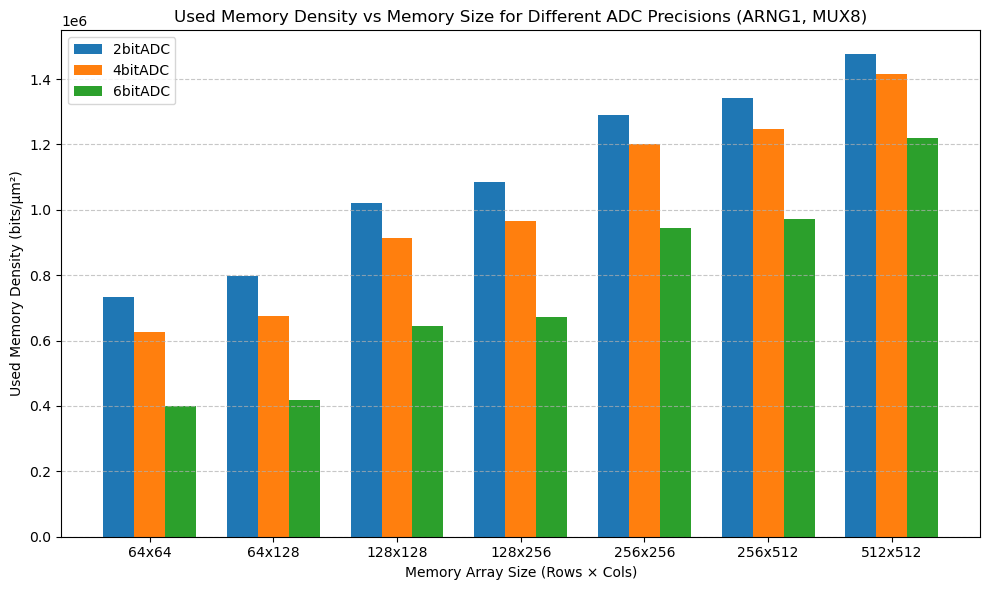

In [89]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

# 要比较的 ADC 精度
adc_precisions = ["2bitADC", "4bitADC", "6bitADC"]

# 基础路径
base_folder = "./Data/simulation/ps_sram"

# 用于存储不同 ADC 精度的数据
adc_data_dict = {}

# 读取每个 ADC 精度的数据
for adc in adc_precisions:
    adc_folder = os.path.join(base_folder, adc, "ARNG1", "mux8", "area")
    adc_files = [f for f in os.listdir(adc_folder) if f.endswith(".json")]
    data_list = []

    for file in adc_files:
        filepath = os.path.join(adc_folder, file)
        with open(filepath, "r") as f:
            data = json.load(f)

        num_rows = data["num_rows"]
        num_cols = data["num_cols"]
        density = data["Used_memory_Density (bits/um^2)"]

        data_list.append({
            "label": f"{num_rows}x{num_cols}",
            "rows": num_rows,
            "cols": num_cols,
            "area": num_rows * num_cols,
            "density": density
        })

    # 按面积排序（确保一致）
    data_list.sort(key=lambda d: d["area"])
    adc_data_dict[adc] = data_list

# 获取所有 memory 尺寸标签（以 3bit 为基准）
memory_sizes = [d["label"] for d in adc_data_dict[adc_precisions[0]]]

# 准备绘图
x = np.arange(len(memory_sizes))
bar_width = 0.25

plt.figure(figsize=(10, 6))

# 画出每个 ADC 精度的柱子
for i, adc in enumerate(adc_precisions):
    memory_density = [d["density"] for d in adc_data_dict[adc]]
    plt.bar(x + (i - 1) * bar_width, memory_density, width=bar_width, label=adc)

# 坐标轴与标题
plt.xticks(x, memory_sizes)
plt.xlabel("Memory Array Size (Rows × Cols)")
plt.ylabel("Used Memory Density (bits/μm²)")
plt.title("Used Memory Density vs Memory Size for Different ADC Precisions (ARNG1, MUX8)")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

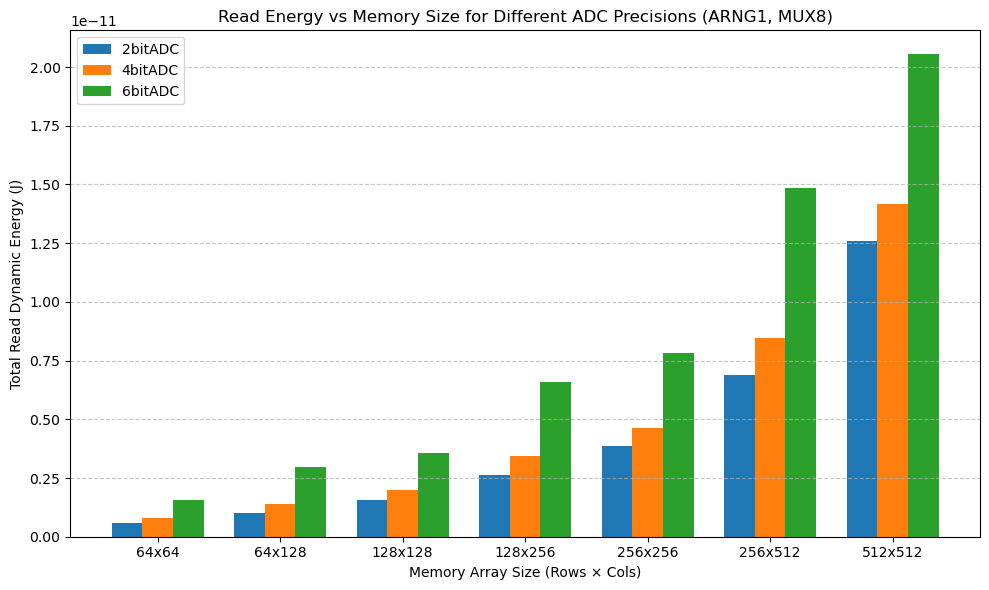

In [92]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

# 定义要比较的 ADC 精度
adc_precisions = ["2bitADC", "4bitADC", "6bitADC"]

# 基础路径
base_folder = "./Data/simulation/ps_sram"

# 存储每种 ADC 精度的数据
adc_data_dict = {}

# 读取各 ADC 精度的数据
for adc in adc_precisions:
    adc_folder = os.path.join(base_folder, adc, "ARNG1", "mux8", "energy")
    adc_files = [f for f in os.listdir(adc_folder) if f.endswith(".json")]
    data_list = []

    for file in adc_files:
        filepath = os.path.join(adc_folder, file)
        with open(filepath, "r") as f:
            data = json.load(f)

        num_rows = data["num_rows"]
        num_cols = data["num_cols"]
        energy = data["Total Read Dynamic Energy (J)"]

        data_list.append({
            "label": f"{num_rows}x{num_cols}",
            "rows": num_rows,
            "cols": num_cols,
            "area": num_rows * num_cols,
            "energy": energy
        })

    # 按面积排序（保证一致）
    data_list.sort(key=lambda d: d["area"])
    adc_data_dict[adc] = data_list

# 使用第一个 ADC 精度的阵列尺寸作为 X 轴标签
memory_sizes = [d["label"] for d in adc_data_dict[adc_precisions[0]]]

# 绘制柱状图
x = np.arange(len(memory_sizes))
bar_width = 0.25

plt.figure(figsize=(10, 6))

for i, adc in enumerate(adc_precisions):
    energies = [d["energy"] for d in adc_data_dict[adc]]
    plt.bar(x + (i - 1) * bar_width, energies, width=bar_width, label=adc)

# 坐标轴与标题
plt.xticks(x, memory_sizes)
plt.xlabel("Memory Array Size (Rows × Cols)")
plt.ylabel("Total Read Dynamic Energy (J)")
plt.title("Read Energy vs Memory Size for Different ADC Precisions (ARNG1, MUX8)")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

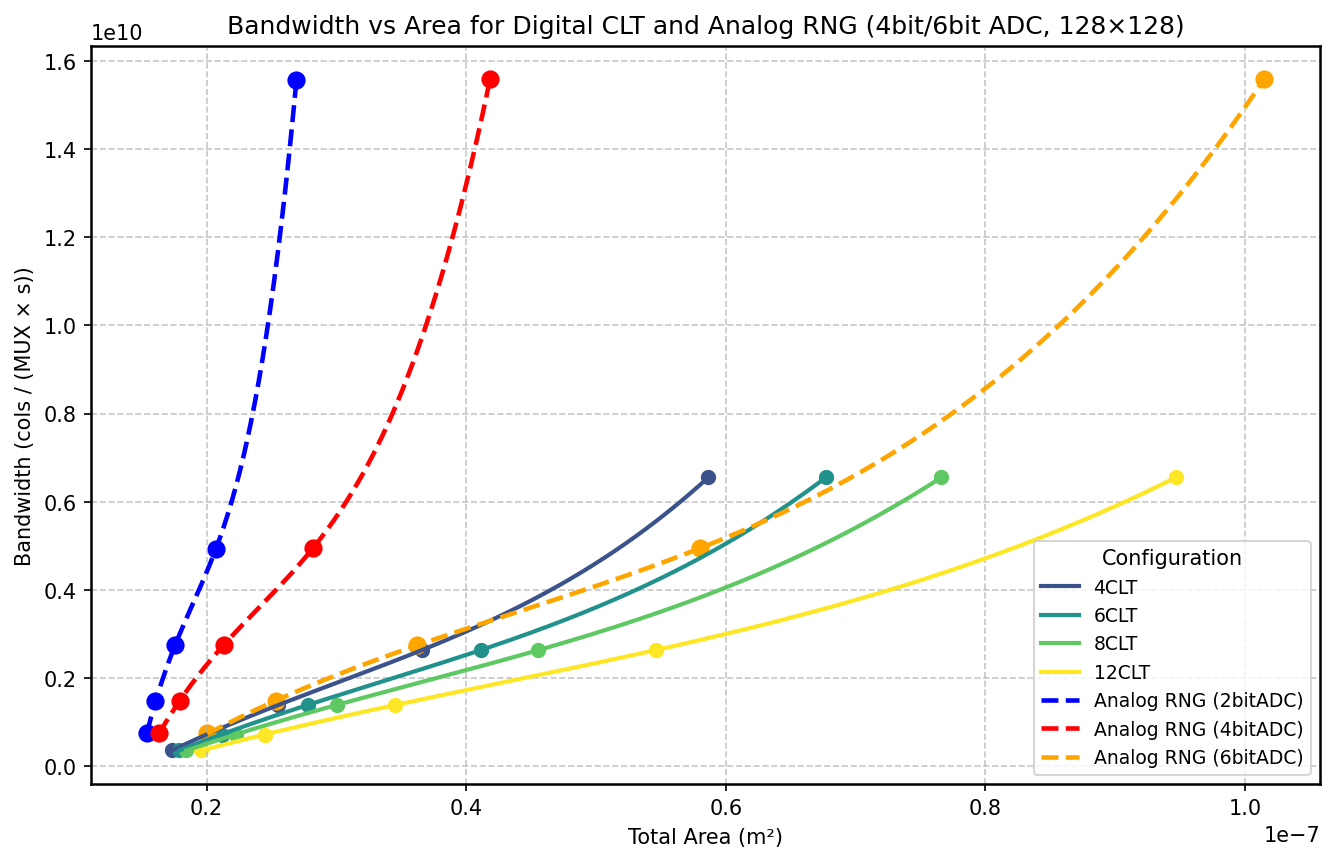

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import json, os

# --------------------------------------
# 1️⃣ Digital SRAM (多CLT)
# --------------------------------------
digital_root = "./Data/simulation/digital_sram"
clt_values = ["2CLT", "4CLT", "6CLT", "8CLT", "12CLT"]
mux_ratios = ["mux1", "mux2", "mux4", "mux8", "mux16"]

colors = plt.cm.viridis(np.linspace(0, 1, len(clt_values)))
plt.figure(figsize=(9, 6))

for color, clt in zip(colors, clt_values):
    base_folder = os.path.join(digital_root, clt)
    results = []

    for mux in mux_ratios:
        mux_value = int(mux.replace("mux", ""))
        area_path = os.path.join(base_folder, mux, "area", "digital_sram_area_data_128x128.json")
        latency_path = os.path.join(base_folder, mux, "latency", "digital_sram_latency_data_128x128.json")

        if not (os.path.exists(area_path) and os.path.exists(latency_path)):
            continue

        with open(area_path, "r") as f:
            area_data = json.load(f)
        total_area = area_data.get("Used Area", None)
        num_cols = area_data.get("num_cols", None)

        with open(latency_path, "r") as f:
            latency_data = json.load(f)
        total_latency = latency_data.get("Total Read Latency (s)", None)

        if total_area and total_latency and num_cols:
            bandwidth = num_cols / (mux_value * total_latency)
            results.append({
                "mux": mux,
                "area": total_area,
                "bandwidth": bandwidth
            })

    if len(results) > 0:
        # 按面积排序
        results.sort(key=lambda r: r["area"])
        areas = np.array([r["area"] for r in results])
        bandwidths = np.array([r["bandwidth"] for r in results])

        # 多项式拟合 (三阶)
        fit_coeffs = np.polyfit(areas, bandwidths, deg=3)
        fit_poly = np.poly1d(fit_coeffs)
        x_fit = np.linspace(areas.min(), areas.max(), 200)
        y_fit = fit_poly(x_fit)

        # 绘制散点 + 曲线
        plt.scatter(areas, bandwidths, s=40, color=color)
        plt.plot(x_fit, y_fit, '-', linewidth=2, color=color, label=f"{clt}")

# --------------------------------------
# 2️⃣ Analog RNG (ps_sram) — 支持多 ADC 精度
# --------------------------------------
adc_bits_list = ["2bitADC","4bitADC", "6bitADC"]  # 要绘制的 ADC 精度
adc_colors = ["blue", "red", "orange"]           # 不同 ADC 精度的颜色
adc_labels = ["Analog RNG (2bitADC)","Analog RNG (4bitADC)", "Analog RNG (6bitADC)"]

for adc_bit, color_adc, label_adc in zip(adc_bits_list, adc_colors, adc_labels):
    ps_sram_base = f"./Data/simulation/ps_sram/{adc_bit}/ARNG1"
    results_ps = []

    for mux in mux_ratios:
        mux_value = int(mux.replace("mux", ""))
        area_path = os.path.join(ps_sram_base, mux, "area", "ps_sram_area_data_128x128.json")
        latency_path = os.path.join(ps_sram_base, mux, "latency", "ps_sram_latency_data_128x128.json")

        if not (os.path.exists(area_path) and os.path.exists(latency_path)):
            continue

        with open(area_path, "r") as f:
            area_data = json.load(f)
        # 注意字段名大小写不同情况
        total_area = area_data.get("used_area", None) or area_data.get("Used_area", None)
        num_cols = area_data.get("num_cols", None)

        with open(latency_path, "r") as f:
            latency_data = json.load(f)
        total_latency = latency_data.get("Total Read Latency (s)", None)

        if total_area and total_latency and num_cols:
            bandwidth = num_cols / (mux_value * total_latency)
            results_ps.append({
                "mux": mux,
                "area": total_area,
                "bandwidth": bandwidth
            })

    if len(results_ps) > 0:
        results_ps.sort(key=lambda r: r["area"])
        areas_ps = np.array([r["area"] for r in results_ps])
        bandwidths_ps = np.array([r["bandwidth"] for r in results_ps])

        # 三阶拟合
        fit_coeffs_ps = np.polyfit(areas_ps, bandwidths_ps, deg=3)
        fit_poly_ps = np.poly1d(fit_coeffs_ps)
        x_fit_ps = np.linspace(areas_ps.min(), areas_ps.max(), 200)
        y_fit_ps = fit_poly_ps(x_fit_ps)

        # 绘制曲线 + 散点
        plt.scatter(areas_ps, bandwidths_ps, s=60, color=color_adc, marker="o")
        plt.plot(x_fit_ps, y_fit_ps, "--", color=color_adc, linewidth=2.2, label=label_adc)

# --------------------------------------
# 3️⃣ 图形美化
# --------------------------------------
plt.xlabel("Total Area (m²)")
plt.ylabel("Bandwidth (cols / (MUX × s))")
plt.title("Bandwidth vs Area for Digital CLT and Analog RNG (4bit/6bit ADC, 128×128)")
plt.legend(title="Configuration", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

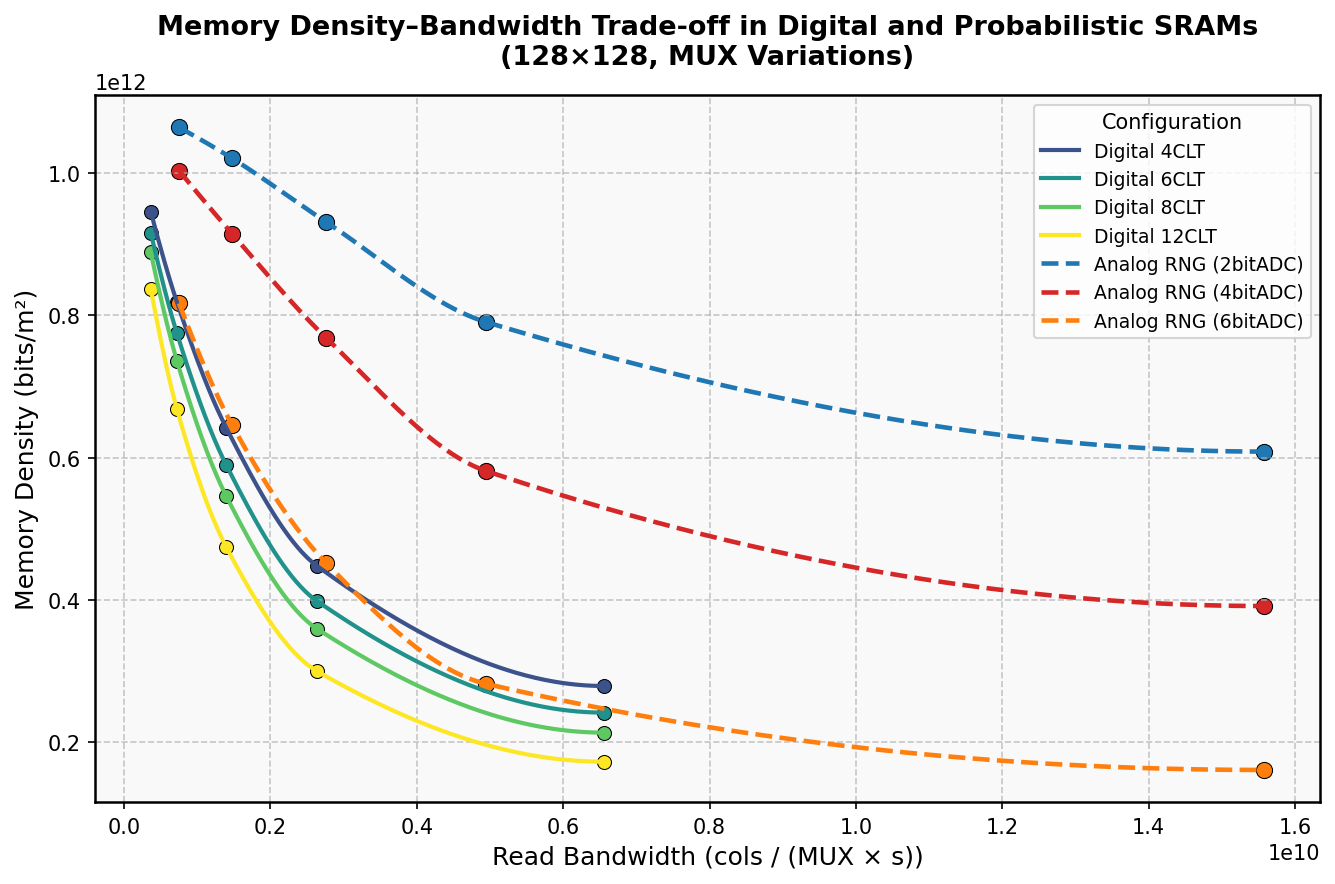

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import json, os

# 尝试导入更稳的拟合器
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    HAS_LOWESS = True
except Exception:
    HAS_LOWESS = False

from scipy.interpolate import make_interp_spline, PchipInterpolator, UnivariateSpline

# ========================== 平滑助手 ==========================
def smooth_xy(x, y, kind="auto", n_points=300, strength=0.5):
    """
    x, y 必须已按 x 升序；返回 (xf, yf)
    kind:
      - "auto"：根据点数自适应
      - "lowess": 局部回归
      - "pchip": 单调分段三次（不振荡）
      - "spline": 平滑样条（带平滑）
      - "cubic": 普通三次样条（k=3），点多时可用
    strength:
      - 对 lowess 是 frac（0.3~0.8）
      - 对 spline 是平滑强度系数（0.1~1.0 越大越平）
    """
    x = np.asarray(x); y = np.asarray(y)
    # 去重（样条/lowess 需要严格递增）
    uniq_idx = np.unique(x, return_index=True)[1]
    x = x[uniq_idx]; y = y[uniq_idx]
    if x.size < 2:
        return x, y

    x_fit = np.linspace(x.min(), x.max(), max(n_points, x.size))

    if kind == "auto":
        n = x.size
        # 点多优先 smooth spline / lowess；点少用 PCHIP
        if n >= 7:
            if HAS_LOWESS:
                # LOWESS 非参数平滑
                frac = np.clip(strength, 0.2, 0.8)
                sm = lowess(y, x, frac=frac, return_sorted=True)
                return sm[:,0], sm[:,1]
            else:
                # 平滑样条：s 与数据量和方差相关，给个经验值
                s = strength * n * np.var(y) if np.var(y) > 0 else 0
                spl = UnivariateSpline(x, y, s=s)
                return x_fit, spl(x_fit)
        elif 4 <= n <= 6:
            # 单调、无振荡
            pchip = PchipInterpolator(x, y)
            return x_fit, pchip(x_fit)
        elif n == 3:
            # 低阶样条更稳
            try:
                spl = make_interp_spline(x, y, k=2)
                return x_fit, spl(x_fit)
            except Exception:
                # 退化到线性
                return x_fit, np.interp(x_fit, x, y)
        else:
            # 两点：线性
            return x_fit, np.interp(x_fit, x, y)

    elif kind == "lowess":
        if not HAS_LOWESS:
            raise RuntimeError("statsmodels 未安装，无法使用 LOWESS")
        frac = np.clip(strength, 0.2, 0.8)
        sm = lowess(y, x, frac=frac, return_sorted=True)
        return sm[:,0], sm[:,1]

    elif kind == "pchip":
        pchip = PchipInterpolator(x, y)
        return x_fit, pchip(x_fit)

    elif kind == "spline":
        s = strength * x.size * np.var(y) if np.var(y) > 0 else 0
        spl = UnivariateSpline(x, y, s=s)
        return x_fit, spl(x_fit)

    elif kind == "cubic":
        spl = make_interp_spline(x, y, k=3)
        return x_fit, spl(x_fit)

    else:
        # 默认线性
        return x_fit, np.interp(x_fit, x, y)

# ========================== 数据收集与绘图（Density vs Bandwidth） ==========================
digital_root = "./Data/simulation/digital_sram"
ps_sram_root = "./Data/simulation/ps_sram"
mux_ratios = ["mux1", "mux2", "mux4", "mux8", "mux16"]

clt_values = ["2CLT", "4CLT", "6CLT", "8CLT", "12CLT"]
adc_bits_list = ["2bitADC", "4bitADC", "6bitADC"]

colors_digital = plt.cm.viridis(np.linspace(0, 1, len(clt_values)))
adc_colors = {"2bitADC":"#1f77b4", "4bitADC":"#d62728", "6bitADC":"#ff7f0e"}
adc_labels = {"2bitADC":"Analog RNG (2bitADC)",
              "4bitADC":"Analog RNG (4bitADC)",
              "6bitADC":"Analog RNG (6bitADC)"}

plt.figure(figsize=(9, 6))

# ---- Digital 多 CLT ----
for color, clt in zip(colors_digital, clt_values):
    base_folder = os.path.join(digital_root, clt)
    results = []
    for mux in mux_ratios:
        mux_value = int(mux.replace("mux", ""))
        area_path = os.path.join(base_folder, mux, "area", "digital_sram_area_data_128x128.json")
        latency_path = os.path.join(base_folder, mux, "latency", "digital_sram_latency_data_128x128.json")
        if not (os.path.exists(area_path) and os.path.exists(latency_path)):
            continue
        with open(area_path, "r") as f:
            area_data = json.load(f)
        total_area = area_data.get("Used Area", None)
        nr = area_data.get("num_rows", None); nc = area_data.get("num_cols", None)
        with open(latency_path, "r") as f:
            latency_data = json.load(f)
        t = latency_data.get("Total Read Latency (s)", None)
        if total_area and t and nr and nc:
            bw = nc / (mux_value * t)
            dens = (nr * nc) / total_area
            results.append({"bw": bw, "dens": dens})
    if len(results) >= 2:
        results.sort(key=lambda r: r["bw"])
        x = np.array([r["bw"] for r in results])
        y = np.array([r["dens"] for r in results])

        # Digital 用平滑样条或 LOWESS（点通常较多）
        xf, yf = smooth_xy(x, y, kind="auto", strength=0.4)
        plt.scatter(x, y, s=45, color=color, edgecolor='black', linewidth=0.5)
        plt.plot(xf, yf, '-', linewidth=2, color=color, label=f"Digital {clt}")

# ---- Analog RNG 多 ADC ----
for adc_bit in adc_bits_list:
    color_adc = adc_colors[adc_bit]
    label_adc = adc_labels[adc_bit]
    ps_base = f"{ps_sram_root}/{adc_bit}/ARNG1"
    results_ps = []
    for mux in mux_ratios:
        mux_value = int(mux.replace("mux", ""))
        area_path = os.path.join(ps_base, mux, "area", "ps_sram_area_data_128x128.json")
        latency_path = os.path.join(ps_base, mux, "latency", "ps_sram_latency_data_128x128.json")
        if not (os.path.exists(area_path) and os.path.exists(latency_path)):
            continue
        with open(area_path, "r") as f:
            area_data = json.load(f)
        total_area = area_data.get("Used_area", None) or area_data.get("used_area", None)
        nr = area_data.get("num_rows", None); nc = area_data.get("num_cols", None)
        with open(latency_path, "r") as f:
            latency_data = json.load(f)
        t = latency_data.get("Total Read Latency (s)", None)
        if total_area and t and nr and nc:
            bw = nc / (mux_value * t)
            dens = (nr * nc) / total_area
            results_ps.append({"bw": bw, "dens": dens})
    if len(results_ps) >= 2:
        results_ps.sort(key=lambda r: r["bw"])
        x = np.array([r["bw"] for r in results_ps])
        y = np.array([r["dens"] for r in results_ps])

        # 6bitADC 更“滑”：优先 LOWESS（若有）或 PCHIP
        if adc_bit == "6bitADC":
            kind = "lowess" if HAS_LOWESS and x.size >= 5 else ("pchip" if x.size >= 4 else "auto")
            strength = 0.6  # LOWESS 的 frac；或样条平滑强度
            xf, yf = smooth_xy(x, y, kind=kind, strength=strength)
        else:
            # 2/4bit 用 auto 即可
            xf, yf = smooth_xy(x, y, kind="auto", strength=0.4)

        plt.scatter(x, y, s=60, color=color_adc, marker="o", edgecolor='black', linewidth=0.5)
        plt.plot(xf, yf, "--", color=color_adc, linewidth=2.2, label=label_adc)

# ========================== 外观 ==========================
plt.xlabel("Read Bandwidth (cols / (MUX × s))", fontsize=12)
plt.ylabel("Memory Density (bits/m²)", fontsize=12)
plt.title("Memory Density–Bandwidth Trade-off in Digital and Probabilistic SRAMs\n(128×128, MUX Variations)",
          fontsize=13, fontweight='bold', pad=15)
plt.legend(title="Configuration", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.gca().set_facecolor("#F9F9F9")

# 可选：跨度大时用对数坐标
# plt.xscale("log"); plt.yscale("log")

plt.show()

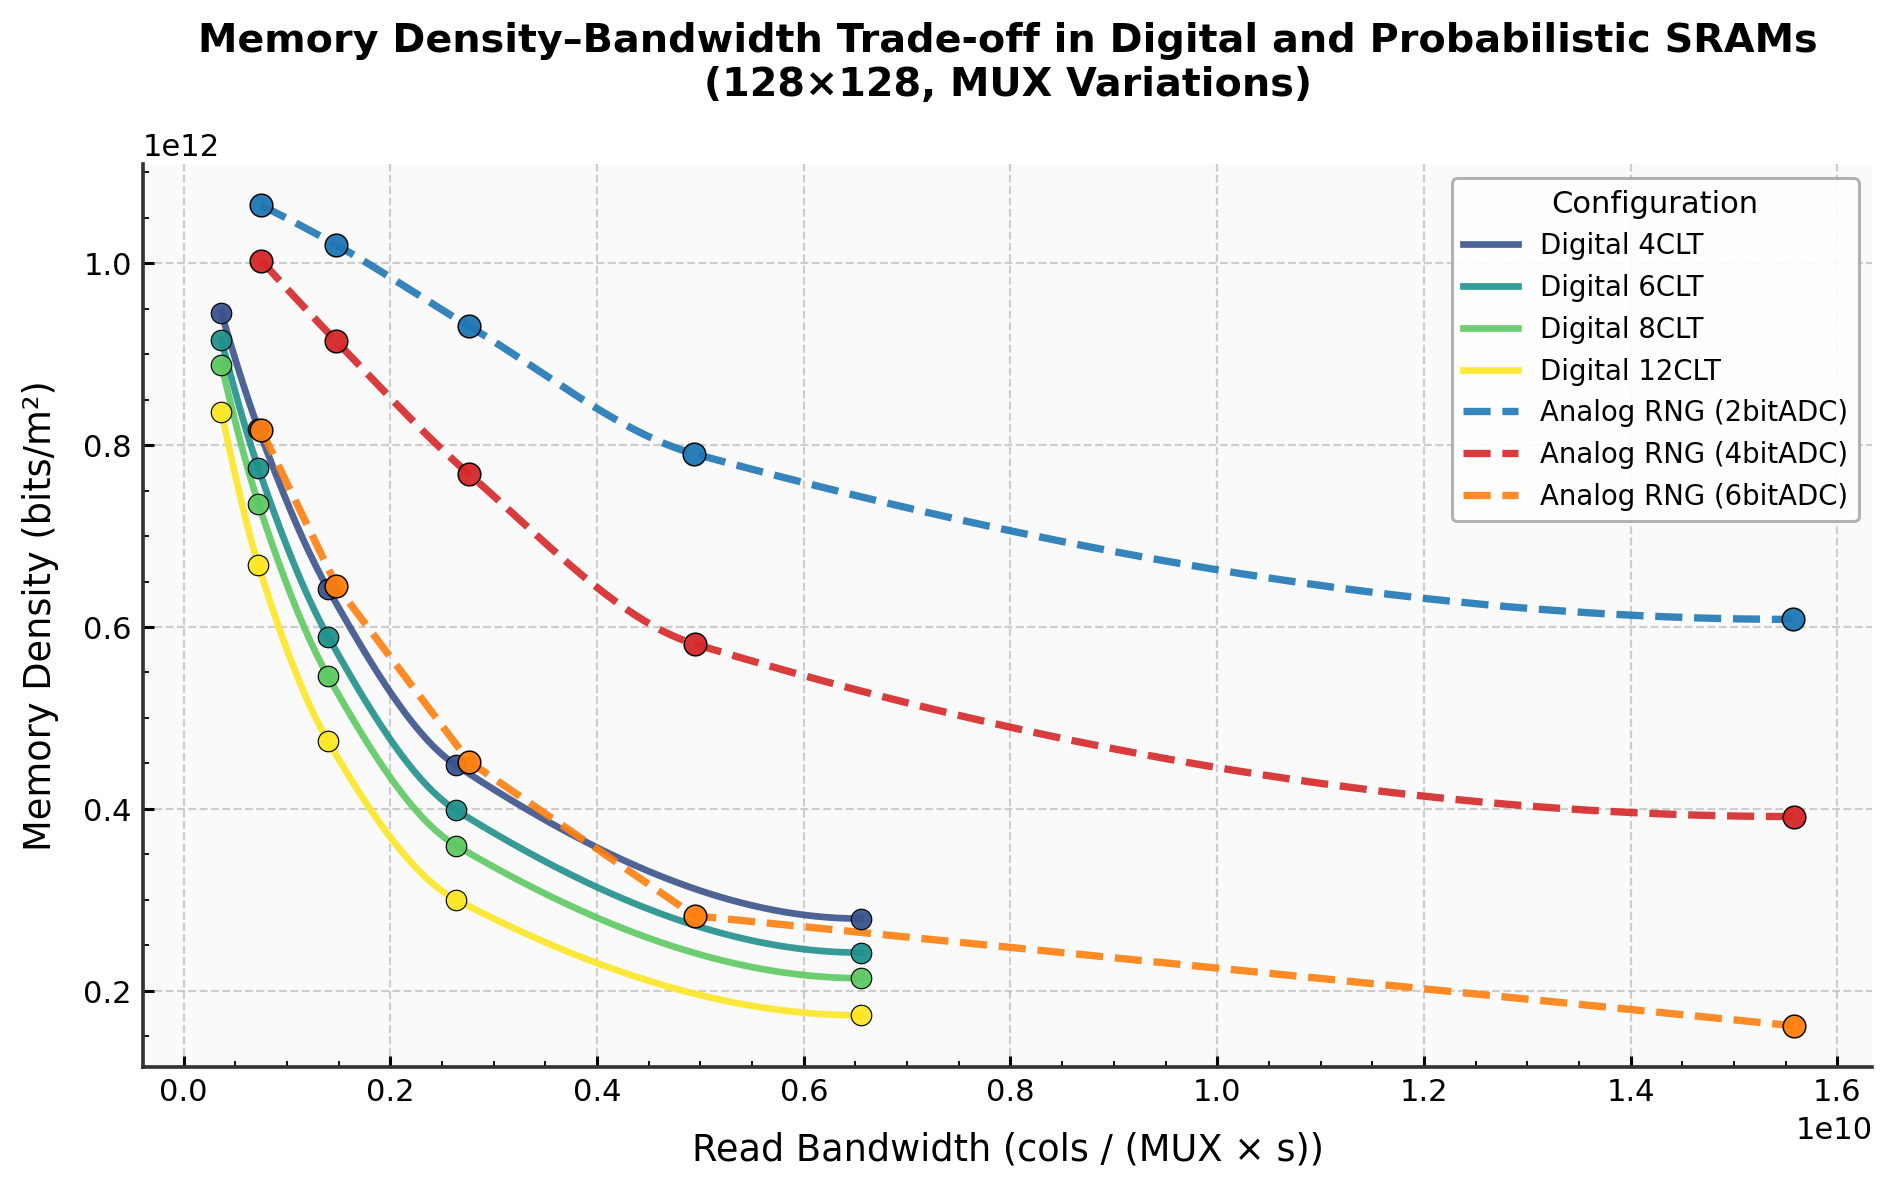

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import json, os
from scipy.interpolate import make_interp_spline, PchipInterpolator, UnivariateSpline

# ========================== 平滑助手（自带 fallback） ==========================
def smooth_xy(x, y, kind="auto", n_points=300, strength=0.5):
    """
    自适应平滑函数，不依赖 statsmodels；
    如果存在 statsmodels.lowess 会自动使用，否则自动 fallback。
    """
    # 尝试导入 LOWESS（可选）
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        HAS_LOWESS = True
    except Exception:
        HAS_LOWESS = False
        lowess = None

    x = np.asarray(x)
    y = np.asarray(y)

    uniq_idx = np.unique(x, return_index=True)[1]
    x = x[uniq_idx]
    y = y[uniq_idx]
    if x.size < 2:
        return x, y

    x_fit = np.linspace(x.min(), x.max(), max(n_points, x.size))

    if kind == "auto":
        n = x.size
        if n >= 7:
            if HAS_LOWESS:
                frac = np.clip(strength, 0.25, 0.7)
                sm = lowess(y, x, frac=frac, return_sorted=True)
                return sm[:, 0], sm[:, 1]
            else:
                s = strength * n * np.var(y) if np.var(y) > 0 else 0
                spl = UnivariateSpline(x, y, s=s)
                return x_fit, spl(x_fit)
        elif 4 <= n <= 6:
            pchip = PchipInterpolator(x, y)
            return x_fit, pchip(x_fit)
        elif n == 3:
            spl = make_interp_spline(x, y, k=2)
            return x_fit, spl(x_fit)
        else:
            return x_fit, np.interp(x_fit, x, y)

    elif kind == "lowess" and HAS_LOWESS:
        frac = np.clip(strength, 0.3, 0.7)
        sm = lowess(y, x, frac=frac, return_sorted=True)
        return sm[:, 0], sm[:, 1]

    elif kind == "pchip":
        pchip = PchipInterpolator(x, y)
        return x_fit, pchip(x_fit)

    elif kind == "spline":
        s = strength * x.size * np.var(y) if np.var(y) > 0 else 0
        spl = UnivariateSpline(x, y, s=s)
        return x_fit, spl(x_fit)

    elif kind == "cubic":
        spl = make_interp_spline(x, y, k=3)
        return x_fit, spl(x_fit)

    else:
        return x_fit, np.interp(x_fit, x, y)

# ========================== 图形设置 ==========================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.linewidth": 1.2,
    "axes.edgecolor": "#333333",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": "#AAAAAA",
    "figure.dpi": 220
})

plt.figure(figsize=(8.8, 5.6))

# ========================== 模拟输入路径 ==========================
digital_root = "./Data/simulation/digital_sram"
ps_sram_root = "./Data/simulation/ps_sram"
mux_ratios = ["mux1", "mux2", "mux4", "mux8", "mux16"]
clt_values = ["2CLT", "4CLT", "6CLT", "8CLT", "12CLT"]
adc_bits_list = ["2bitADC", "4bitADC", "6bitADC"]

colors_digital = plt.cm.viridis(np.linspace(0, 1, len(clt_values)))
adc_colors = {"2bitADC": "#1f77b4", "4bitADC": "#d62728", "6bitADC": "#ff7f0e"}
adc_labels = {
    "2bitADC": "Analog RNG (2bitADC)",
    "4bitADC": "Analog RNG (4bitADC)",
    "6bitADC": "Analog RNG (6bitADC)"
}

# ========================== Digital SRAM (蓝绿系) ==========================
for color, clt in zip(colors_digital, clt_values):
    base_folder = os.path.join(digital_root, clt)
    results = []
    for mux in mux_ratios:
        mux_value = int(mux.replace("mux", ""))
        area_path = os.path.join(base_folder, mux, "area", "digital_sram_area_data_128x128.json")
        latency_path = os.path.join(base_folder, mux, "latency", "digital_sram_latency_data_128x128.json")
        if not (os.path.exists(area_path) and os.path.exists(latency_path)):
            continue
        with open(area_path) as f:
            area_data = json.load(f)
        with open(latency_path) as f:
            latency_data = json.load(f)
        total_area = area_data.get("Used Area")
        nr = area_data.get("num_rows")
        nc = area_data.get("num_cols")
        t = latency_data.get("Total Read Latency (s)")
        if total_area and t and nr and nc:
            bw = nc / (mux_value * t)
            dens = (nr * nc) / total_area
            results.append({"bw": bw, "dens": dens})

    if len(results) >= 2:
        results.sort(key=lambda r: r["bw"])
        x = np.array([r["bw"] for r in results])
        y = np.array([r["dens"] for r in results])
        xf, yf = smooth_xy(x, y, kind="auto", strength=0.4)
        plt.plot(xf, yf, '-', color=color, linewidth=2.2, alpha=0.9, label=f"Digital {clt}")
        plt.scatter(x, y, s=45, color=color, edgecolor='black', linewidth=0.4, zorder=5, alpha=0.95)

# ========================== Analog ps-SRAM (红橙系) ==========================
for adc_bit in adc_bits_list:
    color_adc = adc_colors[adc_bit]
    label_adc = adc_labels[adc_bit]
    ps_base = f"{ps_sram_root}/{adc_bit}/ARNG1"
    results_ps = []
    for mux in mux_ratios:
        mux_value = int(mux.replace("mux", ""))
        area_path = os.path.join(ps_base, mux, "area", "ps_sram_area_data_128x128.json")
        latency_path = os.path.join(ps_base, mux, "latency", "ps_sram_latency_data_128x128.json")
        if not (os.path.exists(area_path) and os.path.exists(latency_path)):
            continue
        with open(area_path) as f:
            area_data = json.load(f)
        with open(latency_path) as f:
            latency_data = json.load(f)
        total_area = area_data.get("Used_area") or area_data.get("used_area")
        nr = area_data.get("num_rows")
        nc = area_data.get("num_cols")
        t = latency_data.get("Total Read Latency (s)")
        if total_area and t and nr and nc:
            bw = nc / (mux_value * t)
            dens = (nr * nc) / total_area
            results_ps.append({"bw": bw, "dens": dens})

    if len(results_ps) >= 2:
        results_ps.sort(key=lambda r: r["bw"])
        x = np.array([r["bw"] for r in results_ps])
        y = np.array([r["dens"] for r in results_ps])
        kind = "lowess" if adc_bit == "6bitADC" else "auto"
        strength = 0.6 if adc_bit == "6bitADC" else 0.4
        xf, yf = smooth_xy(x, y, kind=kind, strength=strength)
        plt.plot(xf, yf, '--', color=color_adc, linewidth=2.4, alpha=0.9, label=label_adc)
        plt.scatter(x, y, s=55, color=color_adc, edgecolor='black', linewidth=0.5, zorder=6, alpha=0.95)

# ========================== 图形美化 ==========================
plt.xlabel("Read Bandwidth (cols / (MUX × s))", fontsize=12)
plt.ylabel("Memory Density (bits/m²)", fontsize=12)
plt.title("Memory Density–Bandwidth Trade-off in Digital and Probabilistic SRAMs\n(128×128, MUX Variations)",
          fontsize=13, fontweight='bold', pad=12)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_facecolor("#FAFAFA")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.6, linewidth=0.7)
ax.set_axisbelow(True)
plt.legend(
    title="Configuration",
    fontsize=9,
    title_fontsize=10,
    loc='best',
    framealpha=0.9,
    facecolor='white',
    edgecolor='#AAAAAA'
)
plt.tight_layout(pad=1.4)
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/Density vs BW tradeoff.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

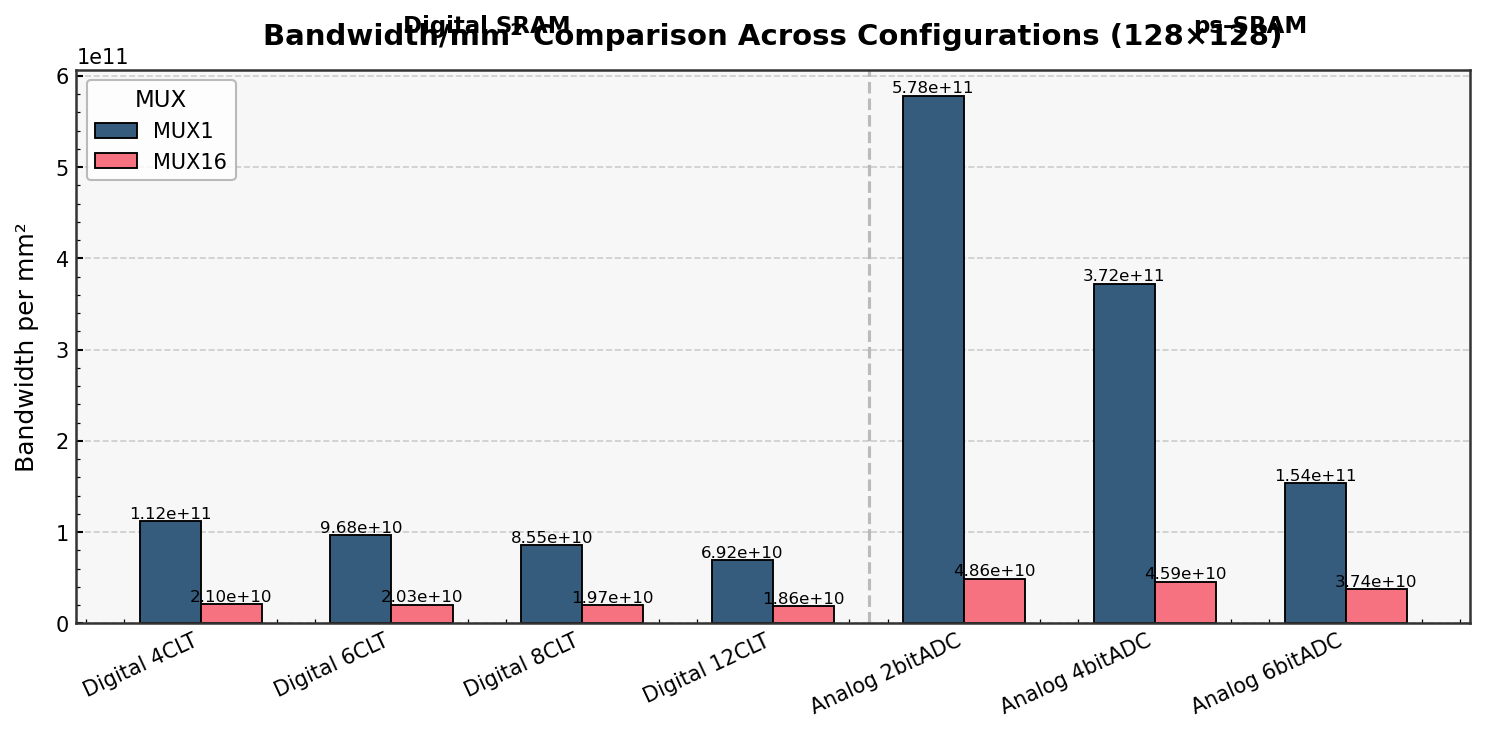

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import json, os


# ========================== 计算带宽/mm² ==========================
def compute_bw_per_mm2(area_path, latency_path, mux_value):
    if not (os.path.exists(area_path) and os.path.exists(latency_path)):
        return None

    with open(area_path) as f:
        area_data = json.load(f)
    with open(latency_path) as f:
        lat_data = json.load(f)

    nr = area_data.get("num_rows")
    nc = area_data.get("num_cols")
    used_area = area_data.get("Used Area") or area_data.get("Used_area")

    latency = lat_data.get("Total Read Latency (s)")

    if not (nr and nc and used_area and latency):
        return None

    bw = nc / (mux_value * latency)                    # read bandwidth
    dens = (nr * nc) / used_area                      # bits per um2
    dens_mm2 = dens * 1e6                              # convert to per mm2

    return bw/used_area/1e6                     # bandwidth per mm2


# ========================== 输入路径 ==========================
digital_root = "./Data/simulation/digital_sram"
ps_sram_root = "./Data/simulation/ps_sram"

clt_values = ["4CLT", "6CLT", "8CLT", "12CLT"]
adc_bits_list = ["2bitADC", "4bitADC", "6bitADC"]

mux_targets = ["mux1", "mux16"]
mux_numeric = {"mux1": 1, "mux16": 16}


# ========================== 数据收集 ==========================
configs = []
values_mux1 = []
values_mux16 = []

# Digital configs
for clt in clt_values:
    config_name = f"Digital {clt}"
    base_folder = os.path.join(digital_root, clt)

    v1 = compute_bw_per_mm2(
        os.path.join(base_folder, "mux1", "area", "digital_sram_area_data_128x128.json"),
        os.path.join(base_folder, "mux1", "latency", "digital_sram_latency_data_128x128.json"),
        mux_numeric["mux1"]
    )
    v16 = compute_bw_per_mm2(
        os.path.join(base_folder, "mux16", "area", "digital_sram_area_data_128x128.json"),
        os.path.join(base_folder, "mux16", "latency", "digital_sram_latency_data_128x128.json"),
        mux_numeric["mux16"]
    )

    configs.append(config_name)
    values_mux1.append(v1 if v1 else 0)
    values_mux16.append(v16 if v16 else 0)

# Analog configs
for adc in adc_bits_list:
    config_name = f"Analog {adc}"
    base_folder = f"{ps_sram_root}/{adc}/ARNG1"

    v1 = compute_bw_per_mm2(
        os.path.join(base_folder, "mux1", "area", "ps_sram_area_data_128x128.json"),
        os.path.join(base_folder, "mux1", "latency", "ps_sram_latency_data_128x128.json"),
        mux_numeric["mux1"]
    )
    v16 = compute_bw_per_mm2(
        os.path.join(base_folder, "mux16", "area", "ps_sram_area_data_128x128.json"),
        os.path.join(base_folder, "mux16", "latency", "ps_sram_latency_data_128x128.json"),
        mux_numeric["mux16"]
    )

    configs.append(config_name)
    values_mux1.append(v1 if v1 else 0)
    values_mux16.append(v16 if v16 else 0)


# ========================== 绘图区 ==========================
plt.figure(figsize=(10, 5))

x = np.arange(len(configs))
bar_width = 0.32

# 美观配色（科技风）
color_mux1 = "#355C7D"   # 深蓝紫
color_mux16 = "#F67280"  # 柔橘红

plt.bar(
    x - bar_width/2, values_mux1, width=bar_width,
    label="MUX1", color=color_mux1,
    edgecolor='black', linewidth=0.9
)
plt.bar(
    x + bar_width/2, values_mux16, width=bar_width,
    label="MUX16", color=color_mux16,
    edgecolor='black', linewidth=0.9
)

# ========================== 数值标注 ==========================
for i, v in enumerate(values_mux1):
    if v > 0:
        plt.text(i - bar_width/2, v, f"{v:.2e}",
                 fontsize=8, ha='center', va='bottom')

for i, v in enumerate(values_mux16):
    if v > 0:
        plt.text(i + bar_width/2, v, f"{v:.2e}",
                 fontsize=8, ha='center', va='bottom')

# ========================== X 轴美化 ==========================
plt.xticks(x, configs, rotation=25, ha='right', fontsize=10)

# 分隔 Digital vs Analog（专业图特别常见）
digital_count = len(clt_values)
plt.axvline(digital_count - 0.5, color="gray", linestyle="--", alpha=0.5)

plt.text(digital_count/2 - 0.5, max(values_mux1+values_mux16)*1.12,
         "Digital SRAM", ha='center', fontsize=11, fontweight='bold')

plt.text((digital_count + len(adc_bits_list)/2), max(values_mux1+values_mux16)*1.12,
         "ps-SRAM", ha='center', fontsize=11, fontweight='bold')

# ========================== 图形美化 ==========================
plt.ylabel("Bandwidth per mm²", fontsize=12)
plt.title("Bandwidth/mm² Comparison Across Configurations (128×128)",
          fontsize=14, fontweight='bold', pad=12)

ax = plt.gca()
ax.set_facecolor("#F7F7F7")

# 更精致网格线
plt.grid(axis='y', linestyle='--', alpha=0.6, linewidth=0.8)
ax.set_axisbelow(True)

# y 轴科学计数法
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

# 图例
plt.legend(
    title="MUX",
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="#AAAAAA",
    loc="upper left"
)

plt.tight_layout()

# 保存
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/BW_per_mm2_grouped_bar.svg", dpi=300, bbox_inches="tight")
plt.show()

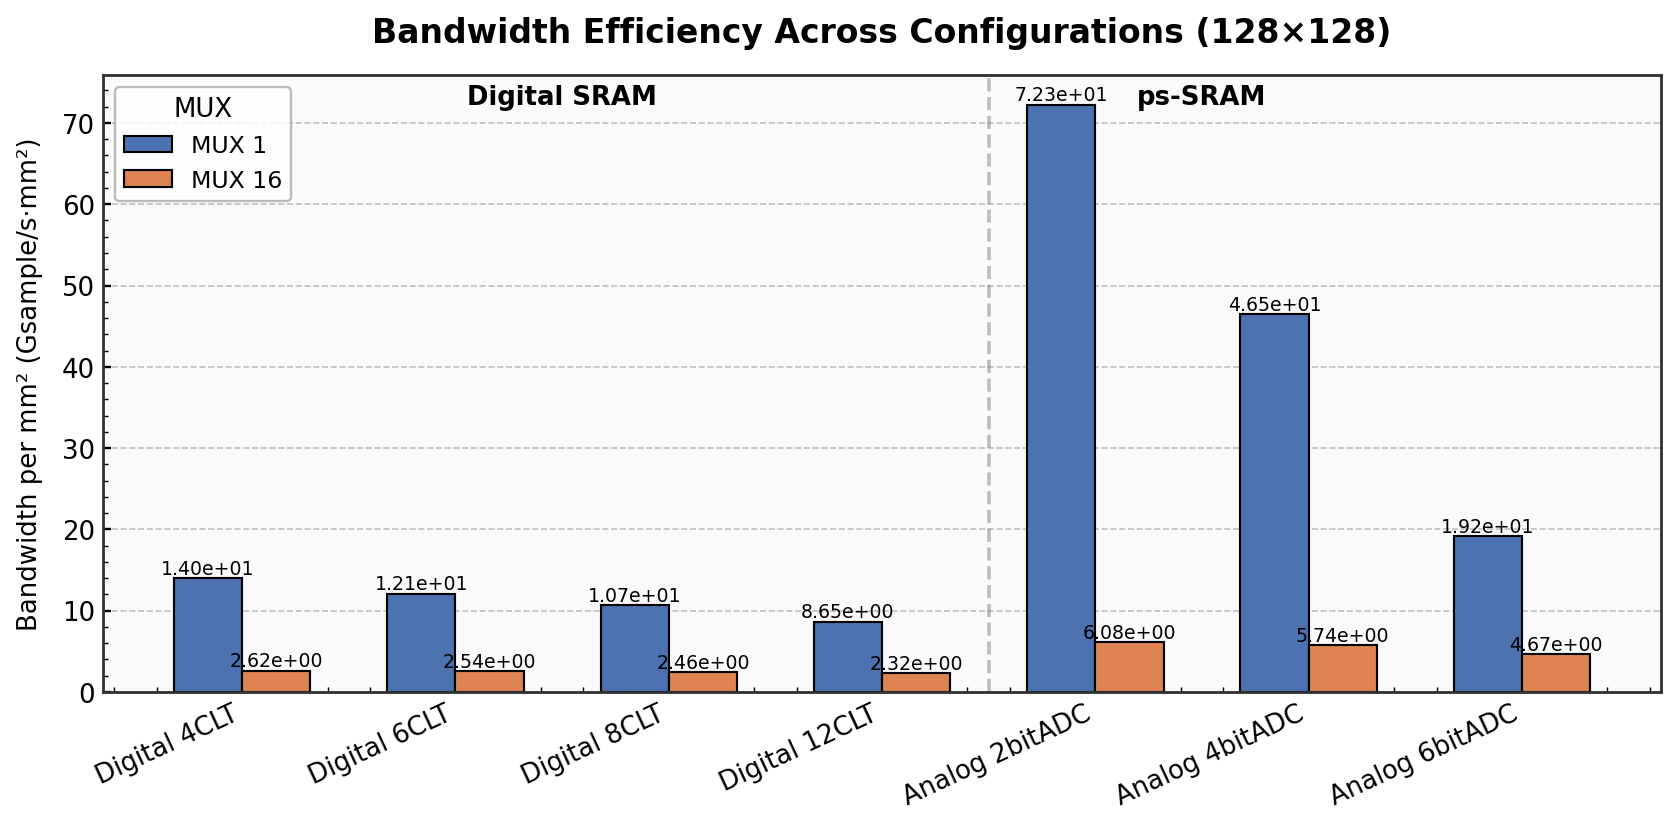

In [136]:
import numpy as np
import matplotlib.pyplot as plt
import json, os

# =====================================================
#                统一论文风格配置
# =====================================================

# SRAM 主色
COLOR_DIGITAL = "#4C72B0"      # 蓝（统一与其他图）
COLOR_PS      = "#55A868"      # 绿
COLOR_PURE    = "#C44E52"      # 红（备用）

# MUX 主色
COLOR_MUX1  = "#4C72B0"        # 深蓝紫
COLOR_MUX16 = "#DD8452"        # 柔橘棕

# 所有图统一风格
plt.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.edgecolor": "#333333",
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "figure.dpi": 170,
    "axes.facecolor": "#FAFAFA",
    "grid.color": "#999999",
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
})

# =====================================================
#              计算 Bandwidth per mm²
# =====================================================

def compute_bw_per_mm2(area_path, latency_path, mux_value):
    if not (os.path.exists(area_path) and os.path.exists(latency_path)):
        return None

    with open(area_path) as f:
        area_data = json.load(f)
    with open(latency_path) as f:
        lat_data = json.load(f)

    nr = area_data.get("num_rows")
    nc = area_data.get("num_cols")
    used_area = area_data.get("Used Area") or area_data.get("Used_area")

    latency = lat_data.get("Total Read Latency (s)")

    if not (nr and nc and used_area and latency):
        return None

    bw = nc / (mux_value * latency)
    return bw/used_area/1e6/8/1e9        # per mm²


# =====================================================
#                    输入路径
# =====================================================
digital_root = "./Data/simulation/digital_sram"
ps_sram_root = "./Data/simulation/ps_sram/65"

clt_values = ["4CLT", "6CLT", "8CLT", "12CLT"]
adc_bits_list = ["2bitADC", "4bitADC", "6bitADC"]

configs = []
values_mux1 = []
values_mux16 = []

# =====================================================
#                Digital SRAM 计算
# =====================================================
for clt in clt_values:
    config_name = f"Digital {clt}"
    base = os.path.join(digital_root, clt)

    v1 = compute_bw_per_mm2(base+"/mux1/area/digital_sram_area_data_128x128.json",
                            base+"/mux1/latency/digital_sram_latency_data_128x128.json", 1)
    v16 = compute_bw_per_mm2(base+"/mux16/area/digital_sram_area_data_128x128.json",
                             base+"/mux16/latency/digital_sram_latency_data_128x128.json", 16)

    configs.append(config_name)
    values_mux1.append(v1 or 0)
    values_mux16.append(v16 or 0)

# =====================================================
#                ps-SRAM（Analog）计算
# =====================================================
for adc in adc_bits_list:
    config_name = f"Analog {adc}"
    base = f"{ps_sram_root}/{adc}/ARNG1"

    v1 = compute_bw_per_mm2(base+"/mux1/area/ps_sram_area_data_128x128.json",
                            base+"/mux1/latency/ps_sram_latency_data_128x128.json", 1)
    v16 = compute_bw_per_mm2(base+"/mux16/area/ps_sram_area_data_128x128.json",
                             base+"/mux16/latency/ps_sram_latency_data_128x128.json", 16)

    configs.append(config_name)
    values_mux1.append(v1 or 0)
    values_mux16.append(v16 or 0)


# =====================================================
#                     绘图区
# =====================================================
plt.figure(figsize=(10, 5))
x = np.arange(len(configs))
bar_width = 0.32

plt.bar(
    x - bar_width/2, values_mux1, width=bar_width,
    label="MUX 1", color=COLOR_MUX1,
    edgecolor="black", linewidth=0.9
)
plt.bar(
    x + bar_width/2, values_mux16, width=bar_width,
    label="MUX 16", color=COLOR_MUX16,
    edgecolor="black", linewidth=0.9
)

# =====================================================
#                     数值标注
# =====================================================
for i, v in enumerate(values_mux1):
    if v > 0:
        plt.text(i - bar_width/2, v, f"{v:.2e}", fontsize=8,
                 ha="center", va="bottom")

for i, v in enumerate(values_mux16):
    if v > 0:
        plt.text(i + bar_width/2, v, f"{v:.2e}", fontsize=8,
                 ha="center", va="bottom")

# =====================================================
#                      X轴分组
# =====================================================
plt.xticks(x, configs, rotation=25, ha="right")

digital_count = len(clt_values)
plt.axvline(digital_count - 0.5, color="gray", linestyle="--", alpha=0.5)

plt.text(
    (digital_count - 1) / 2,
    max(values_mux1+values_mux16) * 1,
    "Digital SRAM", ha="center", fontsize=11, fontweight="bold"
)

plt.text(
    digital_count + (len(adc_bits_list) - 1) / 4,
    max(values_mux1+values_mux16) * 1,
    "ps-SRAM", ha="center", fontsize=11, fontweight="bold"
)

# =====================================================
#                     图形美化
# =====================================================
plt.ylabel("Bandwidth per mm² (Gsample/s·mm²)")
plt.title("Bandwidth Efficiency Across Configurations (128×128)",
          fontsize=14, fontweight="bold", pad=14)

ax = plt.gca()
ax.set_facecolor("#FAFAFA")
ax.set_axisbelow(True)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(
    title="MUX",
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="#AAAAAA",
    loc="upper left"
)

plt.tight_layout()
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/BW per area.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

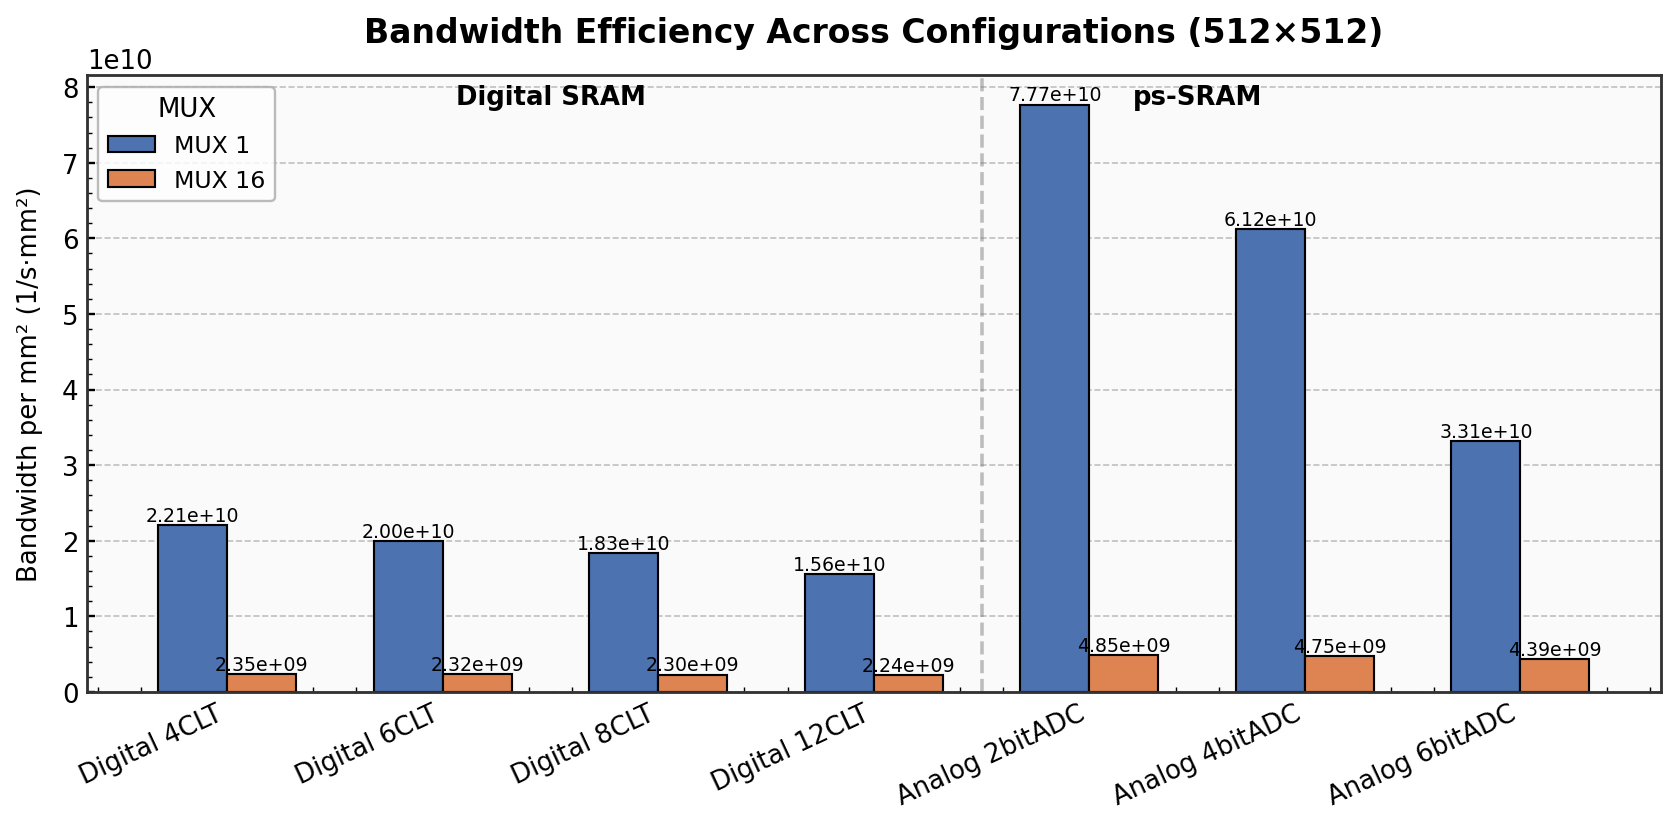

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import json, os

# =====================================================
#                统一论文风格配置
# =====================================================

# SRAM 主色
COLOR_DIGITAL = "#4C72B0"      # 蓝（统一与其他图）
COLOR_PS      = "#55A868"      # 绿
COLOR_PURE    = "#C44E52"      # 红（备用）

# MUX 主色
COLOR_MUX1  = "#4C72B0"        # 深蓝紫
COLOR_MUX16 = "#DD8452"        # 柔橘棕

# 所有图统一风格
plt.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.edgecolor": "#333333",
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "figure.dpi": 170,
    "axes.facecolor": "#FAFAFA",
    "grid.color": "#999999",
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
})

# =====================================================
#              计算 Bandwidth per mm²
# =====================================================

def compute_bw_per_mm2(area_path, latency_path, mux_value):
    if not (os.path.exists(area_path) and os.path.exists(latency_path)):
        return None

    with open(area_path) as f:
        area_data = json.load(f)
    with open(latency_path) as f:
        lat_data = json.load(f)

    nr = area_data.get("num_rows")
    nc = area_data.get("num_cols")
    used_area = area_data.get("Used Area") or area_data.get("Used_area")

    latency = lat_data.get("Total Read Latency (s)")

    if not (nr and nc and used_area and latency):
        return None

    bw = nc / (mux_value * latency)
    return bw/used_area/1e6        # per mm²


# =====================================================
#                    输入路径
# =====================================================
digital_root = "./Data/simulation/digital_sram"
ps_sram_root = "./Data/simulation/ps_sram"

clt_values = ["4CLT", "6CLT", "8CLT", "12CLT"]
adc_bits_list = ["2bitADC", "4bitADC", "6bitADC"]

configs = []
values_mux1 = []
values_mux16 = []

# =====================================================
#                Digital SRAM 计算
# =====================================================
for clt in clt_values:
    config_name = f"Digital {clt}"
    base = os.path.join(digital_root, clt)

    v1 = compute_bw_per_mm2(base+"/mux1/area/digital_sram_area_data_512x512.json",
                            base+"/mux1/latency/digital_sram_latency_data_512x512.json", 1)
    v16 = compute_bw_per_mm2(base+"/mux16/area/digital_sram_area_data_512x512.json",
                             base+"/mux16/latency/digital_sram_latency_data_512x512.json", 16)

    configs.append(config_name)
    values_mux1.append(v1 or 0)
    values_mux16.append(v16 or 0)

# =====================================================
#                ps-SRAM（Analog）计算
# =====================================================
for adc in adc_bits_list:
    config_name = f"Analog {adc}"
    base = f"{ps_sram_root}/{adc}/ARNG1"

    v1 = compute_bw_per_mm2(base+"/mux1/area/ps_sram_area_data_512x512.json",
                            base+"/mux1/latency/ps_sram_latency_data_512x512.json", 1)
    v16 = compute_bw_per_mm2(base+"/mux16/area/ps_sram_area_data_512x512.json",
                             base+"/mux16/latency/ps_sram_latency_data_512x512.json", 16)

    configs.append(config_name)
    values_mux1.append(v1 or 0)
    values_mux16.append(v16 or 0)


# =====================================================
#                     绘图区
# =====================================================
plt.figure(figsize=(10, 5))
x = np.arange(len(configs))
bar_width = 0.32

plt.bar(
    x - bar_width/2, values_mux1, width=bar_width,
    label="MUX 1", color=COLOR_MUX1,
    edgecolor="black", linewidth=0.9
)
plt.bar(
    x + bar_width/2, values_mux16, width=bar_width,
    label="MUX 16", color=COLOR_MUX16,
    edgecolor="black", linewidth=0.9
)

# =====================================================
#                     数值标注
# =====================================================
for i, v in enumerate(values_mux1):
    if v > 0:
        plt.text(i - bar_width/2, v, f"{v:.2e}", fontsize=8,
                 ha="center", va="bottom")

for i, v in enumerate(values_mux16):
    if v > 0:
        plt.text(i + bar_width/2, v, f"{v:.2e}", fontsize=8,
                 ha="center", va="bottom")

# =====================================================
#                      X轴分组
# =====================================================
plt.xticks(x, configs, rotation=25, ha="right")

digital_count = len(clt_values)
plt.axvline(digital_count - 0.5, color="gray", linestyle="--", alpha=0.5)

plt.text(
    (digital_count - 1) / 2,
    max(values_mux1+values_mux16) * 1,
    "Digital SRAM", ha="center", fontsize=11, fontweight="bold"
)

plt.text(
    digital_count + (len(adc_bits_list) - 1) / 4,
    max(values_mux1+values_mux16) * 1,
    "ps-SRAM", ha="center", fontsize=11, fontweight="bold"
)

# =====================================================
#                     图形美化
# =====================================================
plt.ylabel("Bandwidth per mm² (1/s·mm²)")
plt.title("Bandwidth Efficiency Across Configurations (512×512)",
          fontsize=14, fontweight="bold", pad=14)

ax = plt.gca()
ax.set_facecolor("#FAFAFA")
ax.set_axisbelow(True)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(
    title="MUX",
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="#AAAAAA",
    loc="upper left"
)

plt.tight_layout()
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/BW per area_512_512.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

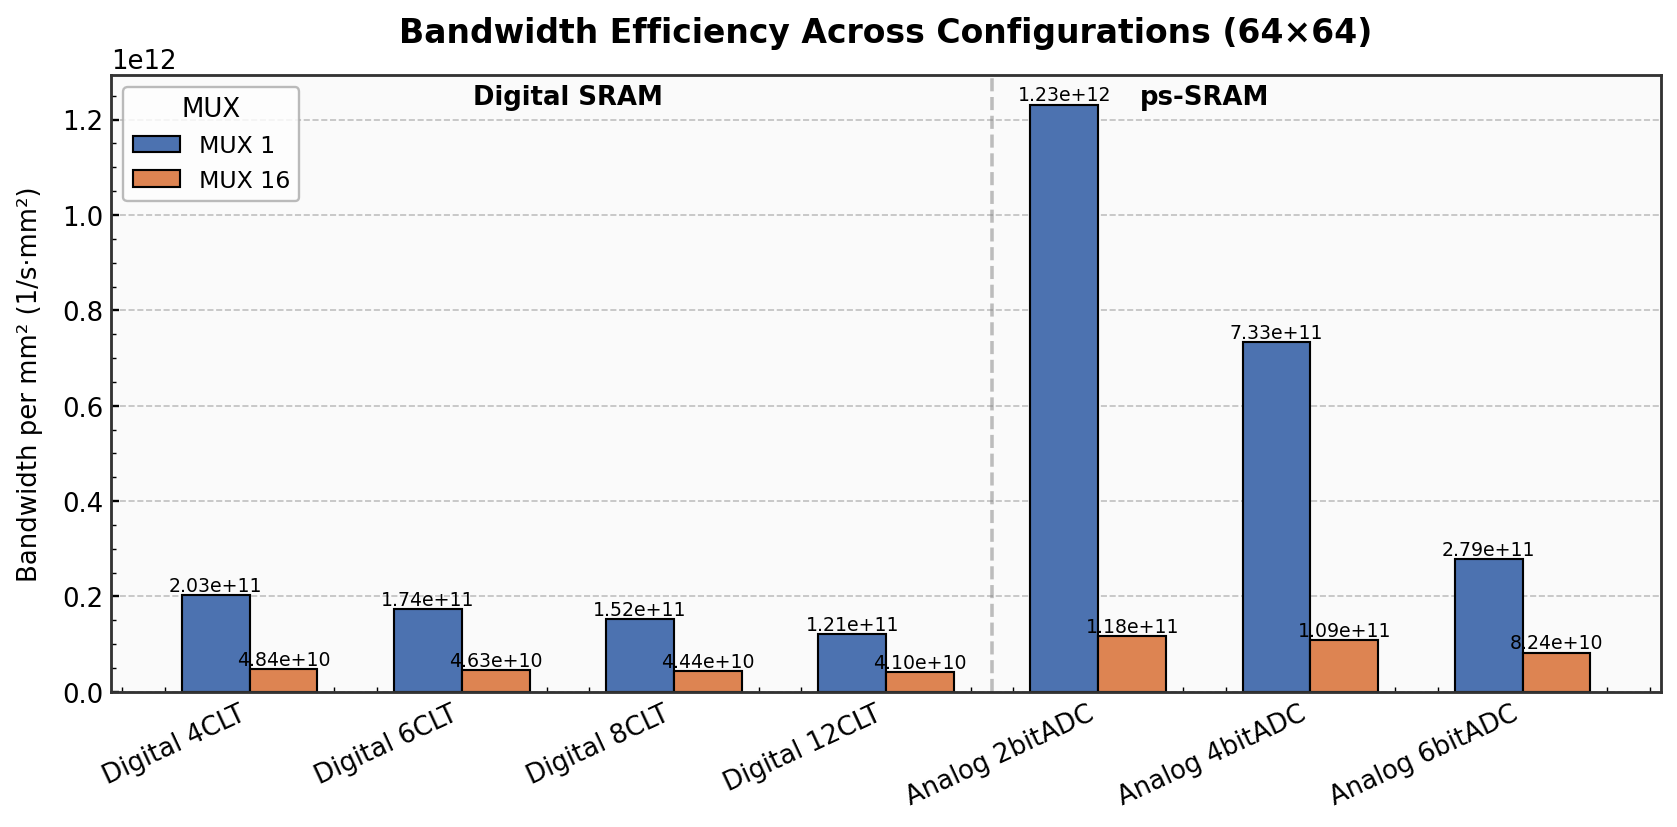

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import json, os

# =====================================================
#                统一论文风格配置
# =====================================================

# SRAM 主色
COLOR_DIGITAL = "#4C72B0"      # 蓝（统一与其他图）
COLOR_PS      = "#55A868"      # 绿
COLOR_PURE    = "#C44E52"      # 红（备用）

# MUX 主色
COLOR_MUX1  = "#4C72B0"        # 深蓝紫
COLOR_MUX16 = "#DD8452"        # 柔橘棕

# 所有图统一风格
plt.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.edgecolor": "#333333",
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "figure.dpi": 170,
    "axes.facecolor": "#FAFAFA",
    "grid.color": "#999999",
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
})

# =====================================================
#              计算 Bandwidth per mm²
# =====================================================

def compute_bw_per_mm2(area_path, latency_path, mux_value):
    if not (os.path.exists(area_path) and os.path.exists(latency_path)):
        return None

    with open(area_path) as f:
        area_data = json.load(f)
    with open(latency_path) as f:
        lat_data = json.load(f)

    nr = area_data.get("num_rows")
    nc = area_data.get("num_cols")
    used_area = area_data.get("Used Area") or area_data.get("Used_area")

    latency = lat_data.get("Total Read Latency (s)")

    if not (nr and nc and used_area and latency):
        return None

    bw = nc / (mux_value * latency)
    return bw/used_area/1e6        # per mm²


# =====================================================
#                    输入路径
# =====================================================
digital_root = "./Data/simulation/digital_sram"
ps_sram_root = "./Data/simulation/ps_sram/65"

clt_values = ["4CLT", "6CLT", "8CLT", "12CLT"]
adc_bits_list = ["2bitADC", "4bitADC", "6bitADC"]

configs = []
values_mux1 = []
values_mux16 = []

# =====================================================
#                Digital SRAM 计算
# =====================================================
for clt in clt_values:
    config_name = f"Digital {clt}"
    base = os.path.join(digital_root, clt)

    v1 = compute_bw_per_mm2(base+"/mux1/area/digital_sram_area_data_64x64.json",
                            base+"/mux1/latency/digital_sram_latency_data_64x64.json", 1)
    v16 = compute_bw_per_mm2(base+"/mux16/area/digital_sram_area_data_64x64.json",
                             base+"/mux16/latency/digital_sram_latency_data_64x64.json", 16)

    configs.append(config_name)
    values_mux1.append(v1 or 0)
    values_mux16.append(v16 or 0)

# =====================================================
#                ps-SRAM（Analog）计算
# =====================================================
for adc in adc_bits_list:
    config_name = f"Analog {adc}"
    base = f"{ps_sram_root}/{adc}/ARNG1"

    v1 = compute_bw_per_mm2(base+"/mux1/area/ps_sram_area_data_64x64.json",
                            base+"/mux1/latency/ps_sram_latency_data_64x64.json", 1)
    v16 = compute_bw_per_mm2(base+"/mux16/area/ps_sram_area_data_64x64.json",
                             base+"/mux16/latency/ps_sram_latency_data_64x64.json", 16)

    configs.append(config_name)
    values_mux1.append(v1 or 0)
    values_mux16.append(v16 or 0)


# =====================================================
#                     绘图区
# =====================================================
plt.figure(figsize=(10, 5))
x = np.arange(len(configs))
bar_width = 0.32

plt.bar(
    x - bar_width/2, values_mux1, width=bar_width,
    label="MUX 1", color=COLOR_MUX1,
    edgecolor="black", linewidth=0.9
)
plt.bar(
    x + bar_width/2, values_mux16, width=bar_width,
    label="MUX 16", color=COLOR_MUX16,
    edgecolor="black", linewidth=0.9
)

# =====================================================
#                     数值标注
# =====================================================
for i, v in enumerate(values_mux1):
    if v > 0:
        plt.text(i - bar_width/2, v, f"{v:.2e}", fontsize=8,
                 ha="center", va="bottom")

for i, v in enumerate(values_mux16):
    if v > 0:
        plt.text(i + bar_width/2, v, f"{v:.2e}", fontsize=8,
                 ha="center", va="bottom")

# =====================================================
#                      X轴分组
# =====================================================
plt.xticks(x, configs, rotation=25, ha="right")

digital_count = len(clt_values)
plt.axvline(digital_count - 0.5, color="gray", linestyle="--", alpha=0.5)

plt.text(
    (digital_count - 1) / 2,
    max(values_mux1+values_mux16) * 1,
    "Digital SRAM", ha="center", fontsize=11, fontweight="bold"
)

plt.text(
    digital_count + (len(adc_bits_list) - 1) / 4,
    max(values_mux1+values_mux16) * 1,
    "ps-SRAM", ha="center", fontsize=11, fontweight="bold"
)

# =====================================================
#                     图形美化
# =====================================================
plt.ylabel("Bandwidth per mm² (1/s·mm²)")
plt.title("Bandwidth Efficiency Across Configurations (64×64)",
          fontsize=14, fontweight="bold", pad=14)

ax = plt.gca()
ax.set_facecolor("#FAFAFA")
ax.set_axisbelow(True)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(
    title="MUX",
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="#AAAAAA",
    loc="upper left"
)

plt.tight_layout()
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/BW per area_64_64.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

{'num_rows': 64, 'num_cols': 64, 'num_muxed_cols': 8, 'adc_precision': 4, 'Technology': 130, 'Array': 9.43712224e-09, 'WL_Decoder': 2.8540395519999995e-09, 'Pre_Charge': 1.7952829439999999e-09, 'SRAM_Write_Driver': 4.3731251199999995e-09, 'Sense_Amp': 1.5201549999999997e-09, 'ADC': 4.2564339999999996e-09, 'RNG_Block': 1.24355608e-09, 'MUX_Bus': 1.6183439999999998e-10, 'MUX': 3.4524672e-10, 'MUX_Decoder': 2.8482854399999997e-10, 'MUX_Block': 7.919096639999999e-10, 'periphery': 9.81435728e-09, 'Total Area': 3.585555317205748e-08, 'Used Area': 2.62716246e-08, 'Memory_Density (bits/um^2)': 114236.14022477405, 'Used_memory_Density (bits/um^2)': 155909.65775295068}


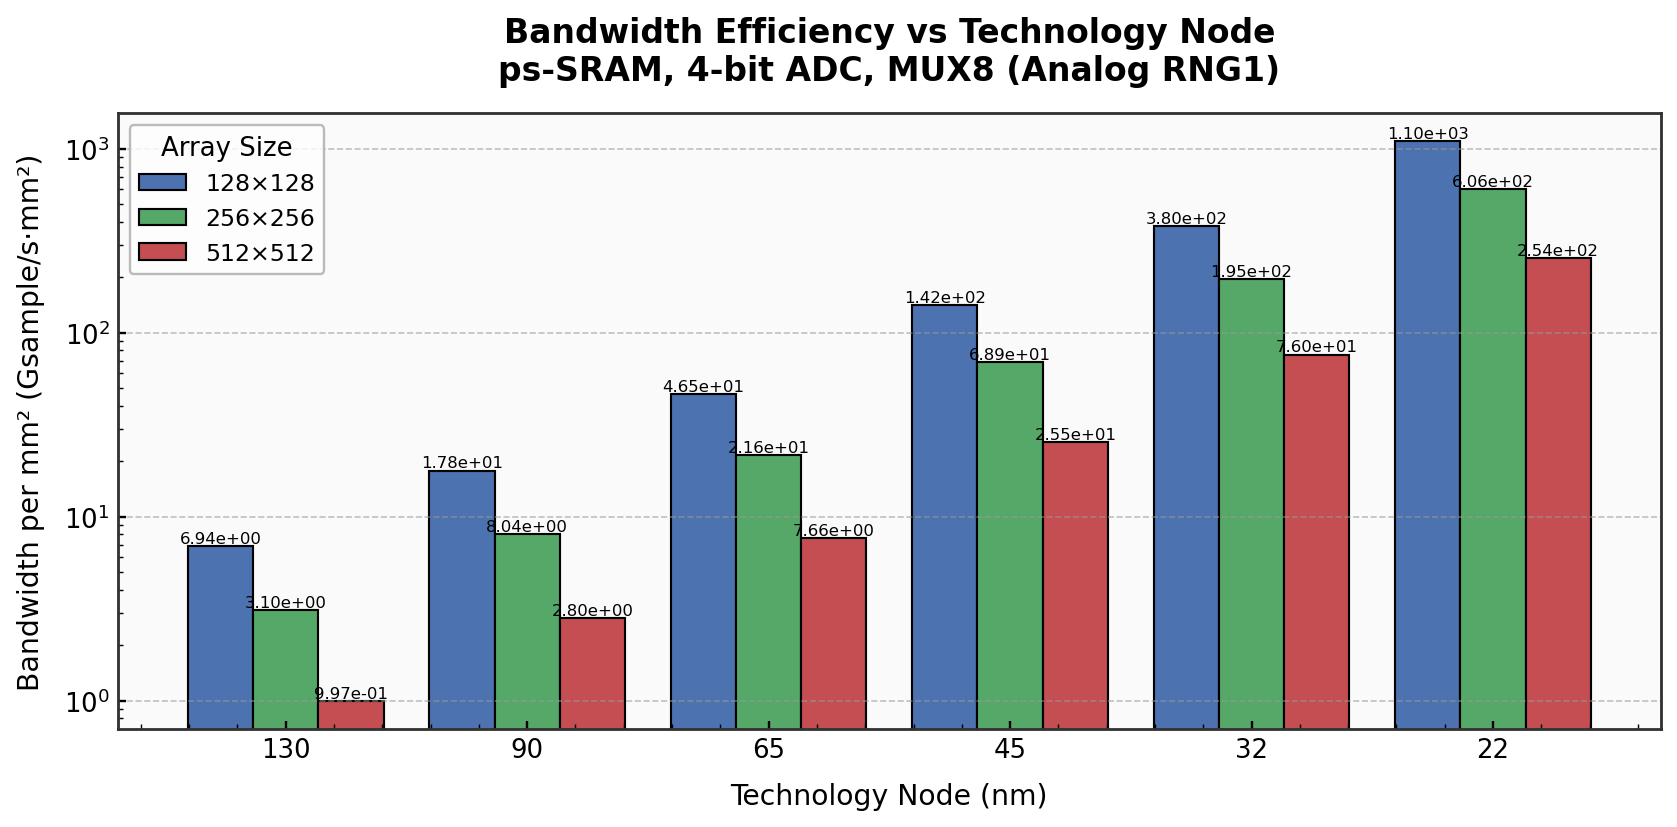

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import json, os


import json

file = "./Data/simulation/ps_sram/130/4bitADC/ARNG1/mux8/area/ps_sram_area_data_64x64.json"
print(json.load(open(file)))
# ===============================================================
# 统一论文风格
# ===============================================================

COLOR_128 = "#4C72B0"    # 蓝
COLOR_256 = "#55A868"   # 绿
COLOR_512 = "#C44E52"   # 红

plt.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.edgecolor": "#333333",
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "figure.dpi": 170,
    "axes.facecolor": "#FAFAFA",
    "grid.color": "#999999",
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
})


# ===============================================================
# 计算带宽 per mm²
# ===============================================================

def compute_bw_per_mm2(area_path, latency_path, mux_value=8):
    if not (os.path.exists(area_path) and os.path.exists(latency_path)):
        return None

    with open(area_path) as f:
        area_data = json.load(f)
    with open(latency_path) as f:
        lat_data = json.load(f)

    nr = area_data.get("num_rows")
    nc = area_data.get("num_cols")

    # ----------- 安全方式读取 Used Area -----------
    used_area = (
        area_data.get("Used Area") or
        area_data.get("Used_area") or
        area_data.get("Used_Area") or
        area_data.get("used_area") or
        area_data.get("used Area") or
        area_data.get("Total Area")  # fallback
    )

    latency = (
        lat_data.get("Total Read Latency (s)") or
        lat_data.get("read_latency") or
        lat_data.get("latency")
    )

    if not (nr and nc and used_area and latency):
        print("⚠ Missing field:", area_path)
        return None

    bw = nc / (mux_value * latency)
    return bw / (used_area * 1e6)*1e-9/8   # convert um² → mm²


# ===============================================================
# Tech nodes & array sizes
# ===============================================================

tech_nodes = ["130", "90", "65", "45", "32", "22"]
array_sizes = [(128, 128), (256, 256), (512, 512)]

# 显示标签
array_labels = ["128×128", "256×256", "512×512"]
array_colors = [COLOR_128, COLOR_256, COLOR_512]

values = {lbl: [] for lbl in array_labels}

# ===============================================================
# 读取数据
# ===============================================================

root = "./Data/simulation/ps_sram"

for tech in tech_nodes:
    base_path = f"{root}/{tech}/4bitADC/ARNG1/mux1"

    for (rows, cols), lbl in zip(array_sizes, array_labels):
        area_file = f"{base_path}/area/ps_sram_area_data_{rows}x{cols}.json"
        lat_file  = f"{base_path}/latency/ps_sram_latency_data_{rows}x{cols}.json"

        bw = compute_bw_per_mm2(area_file, lat_file, mux_value=1)
        values[lbl].append(bw if bw else 0)


# ===============================================================
# 绘图：Technology scaling bar chart
# ===============================================================
plt.figure(figsize=(10, 5))
x = np.arange(len(tech_nodes))
bar_width = 0.27

for i, lbl in enumerate(array_labels):
    plt.bar(
        x + (i - 1) * bar_width,
        values[lbl],
        width=bar_width,
        label=lbl,
        color=array_colors[i],
        edgecolor="black",
        linewidth=0.9
    )

# ===============================================================
# 注释
# ===============================================================
for i, lbl in enumerate(array_labels):
    for j, v in enumerate(values[lbl]):
        if v > 0:
            plt.text(
                j + (i - 1) * bar_width,
                v,
                f"{v:.2e}",
                fontsize=7,
                ha="center",
                va="bottom"
            )

# ===============================================================
# 坐标轴标签
# ===============================================================
plt.xticks(x, tech_nodes, fontsize=11)
plt.xlabel("Technology Node (nm)", fontsize=12)
plt.ylabel("Bandwidth per mm² (Gsample/s·mm²)", fontsize=12)

plt.title(
    "Bandwidth Efficiency vs Technology Node\nps-SRAM, 4-bit ADC, MUX8 (Analog RNG1)",
    fontsize=14,
    fontweight="bold",
    pad=14
)

plt.legend(
    title="Array Size",
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="#AAAAAA",
)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.yscale("log")
plt.tight_layout()

os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/BW per area cross technology.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

